# US Stock Return Prediction(Monthly) — Universe: HXZ microcap exclusion

> **This notebook is a copy of `model_backtest.ipynb`.** Every cell is identical except for
> one extra filtering step right after `y` is constructed (see "Apply universe filter"
> below `## 1. Load Data`): each month, stocks below the NYSE 20th-percentile market cap
> are dropped before any model sees the data — training, hyperparameter tuning, and the
> backtest all use this same filtered universe. This is the "microcap" definition from
> Hou, Xue & Zhang (2020, Review of Financial Studies, "Replicating Anomalies"). Compare
> against `model_backtest.ipynb` (no filter, baseline) and `model_backtest_mild_filter.ipynb`
> (milder bottom-10%-by-market-cap trim). Outputs are saved under `output/hxz/` so they
> never overwrite the baseline notebook's `output/` files.

-   **goal** : predict the monthly return of US stocks
-   **data** : 1972-01-31 ~ 2025-12-31; OSAP + CRSP
-   **model**  
    -   group1: `linear model`(OLS/LASSO/RIDGE) + PCA/PLS
    -   group2: `Tree Model`
    -   group3: `Classifiers`(Logestic Regression/Multinomial Regression)
-   **metrics**
    -   `MSE` to measure the fittness of models
    -   `backtest` to measure the return driven by the model prediction
    -   `shap value` to see which variables have strong prediction power
-   **backtest framework**
    -   Sort the stocks into 10 groups based on their cross-sectional predicted return, then long Q1(highest return group) and short Q10(lowest return group)
    -   calculate the cummulative return


## 0. Preparation

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from tqdm import tqdm
import shap

# ── Paths ────────────────────────────────────────────────────────────────
DATA_DIR   = '.'
PANEL_FILE = os.path.join(DATA_DIR, 'panel_features.parquet')
OUT_DIR    = os.path.join(DATA_DIR, 'output', 'hxz')
os.makedirs(OUT_DIR, exist_ok=True)

# ── Parameters ─────────────────────────────────────────────────────────────
H           = 240    # rolling window in months (20 years)
RANDOM_SEED = 42
N_DECILES   = 10

np.random.seed(RANDOM_SEED)


## 1. Load Data and mark X and Y
Data has been cleaned into panel data form from "ml_project_stk_prediction/feature_engineering.ipynb".

Features at row (permno, t) are known at end of month t.  

Label `y = mthret_{t+1} - Rfree_t` (forward excess return) as our prediction goal, constructed by shifting `mthret` one period forward within each permno group.

In [89]:
panel = pd.read_parquet(PANEL_FILE)
print('Raw shape:', panel.shape)
print('Data sample:', panel.head())

# Construct y as next month's excess return
#sort with permno
panel = panel.sort_values(['permno', 'mthcaldt']).reset_index(drop=True)
#shift within each permno group 
panel['ret_fwd'] = panel.groupby('permno')['mthret'].shift(-1) 
panel['y'] = panel['ret_fwd'] - panel['Rfree']

panel = panel.sort_values(['mthcaldt', 'permno']).reset_index(drop=True)

#check basic traits of the panel to make sure our data has no problem
print('Date range :', panel['mthcaldt'].min().date(), '->', panel['mthcaldt'].max().date())
print('Months     :', panel['mthcaldt'].nunique())
print('Permnos    :', panel['permno'].nunique())
print('y non-NA :', f"{panel['y'].notna().sum():,}  ({panel['y'].notna().mean():.1%})")
print()
print('y stats:')
print(panel['y'].describe())


Raw shape: (2950056, 42)
Data sample:    permno  yyyymm   mthcaldt primaryexch  siccd      size     mom1m   price  \
0   10001  198601 1986-01-31           Q   4920  8.705021       NaN  6.1250   
1   10001  198602 1986-02-28           Q   4920  8.725223  0.065217  6.2500   
2   10001  198603 1986-03-31           Q   4920  8.735173  0.020408  6.3125   
3   10001  198604 1986-04-30           Q   4920  8.745027  0.025352  6.3750   
4   10001  198605 1986-05-30           Q   4920  8.735173  0.009901  6.3125   

     turnover  bm  ...  bm_tbl  bm_tms  bm_dfy  mom12m_tbl  mom12m_tms  \
0   67.756345 NaN  ...     NaN     NaN     NaN         NaN         NaN   
1  108.324873 NaN  ...     NaN     NaN     NaN         NaN         NaN   
2   34.051777 NaN  ...     NaN     NaN     NaN         NaN         NaN   
3   22.836548 NaN  ...     NaN     NaN     NaN         NaN         NaN   
4   22.046701 NaN  ...     NaN     NaN     NaN         NaN         NaN   

   mom12m_dfy  beta_tbl  beta_tms  beta_df

In [ ]:
#Apply universe filter: drop stocks below the NYSE 20th-percentile market cap each month 

n_before    = len(panel)
mktcap      = np.exp(panel['size'])  # size = log(market cap)
nyse_mktcap = mktcap.where(panel['primaryexch'] == 'N')
cutoff      = nyse_mktcap.groupby(panel['mthcaldt']).transform(lambda s: s.quantile(0.20))
panel       = panel[mktcap >= cutoff].reset_index(drop=True)

print('Universe filter   : HXZ microcap exclusion (NYSE 20th-percentile market cap, monthly)')
print(f'Rows before filter: {n_before:,}')
print(f'Rows after filter : {len(panel):,}  ({len(panel)/n_before:.1%} kept)')


Universe filter   : HXZ microcap exclusion (NYSE 20th-percentile market cap, monthly)
Rows before filter: 2,950,056
Rows after filter : 1,253,428  (42.5% kept)


In [91]:
# now we are gonna deal with X-variables
# first check about the variable names and NA values
print(panel.columns.tolist())
print(panel.isna().mean().sort_values(ascending= False))

['permno', 'yyyymm', 'mthcaldt', 'primaryexch', 'siccd', 'size', 'mom1m', 'price', 'turnover', 'bm', 'ep', 'mom12m', 'mom36m', 'gross_profit', 'roa_q', 'asset_growth', 'share_issuance', 'accruals', 'earn_surprise', 'ret_vol', 'idio_vol', 'amihud_illiq', 'beta', 'leverage', 'piotroski_f', 'ind_mom', 'high52', 'rd_intensity', 'tbl', 'tms', 'dfy', 'Rfree', 'bm_tbl', 'bm_tms', 'bm_dfy', 'mom12m_tbl', 'mom12m_tms', 'mom12m_dfy', 'beta_tbl', 'beta_tms', 'beta_dfy', 'mthret', 'ret_fwd', 'y']
piotroski_f       0.948941
rd_intensity      0.575248
ep                0.250290
gross_profit      0.249797
bm_tms            0.229272
bm_dfy            0.229272
bm_tbl            0.229272
bm                0.229272
earn_surprise     0.214044
mom36m            0.169835
roa_q             0.158382
accruals          0.145349
asset_growth      0.140902
leverage          0.114458
beta              0.107199
beta_dfy          0.107199
beta_tms          0.107199
beta_tbl          0.107199
share_issuance    0.1006

In [92]:
FEATURE_COLS = [
    'size', 'mom1m', 'price', 'turnover', 'mom12m', 'high52',
    'ret_vol', 'idio_vol', 'ind_mom', 'beta',
    'share_issuance', 'amihud_illiq', 'leverage',
    'tbl', 'tms', 'dfy',
    'mom12m_tbl', 'mom12m_tms', 'mom12m_dfy',
    'beta_tbl',   'beta_tms',   'beta_dfy',
    'bm', 'gross_profit', 'roa_q', 'asset_growth', 'accruals', 'mom36m',
]

TARGET_COL = 'y'
DATE_COL   = 'mthcaldt'

for _col in FEATURE_COLS:
    panel[_col] = panel[_col].fillna(panel.groupby(DATE_COL)[_col].transform('median'))#same as before, using cross-sectional median imputation

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print()
print('Missing rate per selected feature (after cross-sectional median imputation):')
print(panel[FEATURE_COLS].isnull().mean().sort_values(ascending=False).round(3).to_string())
print()
complete = panel[FEATURE_COLS].dropna().shape[0]
print(f'Complete-case rows (all features non-null): {complete:,}  ({complete/len(panel):.1%})')

Features (28): ['size', 'mom1m', 'price', 'turnover', 'mom12m', 'high52', 'ret_vol', 'idio_vol', 'ind_mom', 'beta', 'share_issuance', 'amihud_illiq', 'leverage', 'tbl', 'tms', 'dfy', 'mom12m_tbl', 'mom12m_tms', 'mom12m_dfy', 'beta_tbl', 'beta_tms', 'beta_dfy', 'bm', 'gross_profit', 'roa_q', 'asset_growth', 'accruals', 'mom36m']

Missing rate per selected feature (after cross-sectional median imputation):
mom36m            0.021
share_issuance    0.021
beta_tms          0.021
beta_tbl          0.021
mom12m_dfy        0.021
mom12m_tms        0.021
mom12m_tbl        0.021
roa_q             0.021
leverage          0.021
bm                0.021
amihud_illiq      0.021
beta              0.021
ind_mom           0.021
idio_vol          0.021
ret_vol           0.021
high52            0.021
mom12m            0.021
beta_dfy          0.021
mom1m             0.001
gross_profit      0.000
asset_growth      0.000
accruals          0.000
size              0.000
dfy               0.000
tbl             

## 2. Helper Functions
Similar the helper function we see in lecutres, now we also create sevel helper functions to reduce the repeatness afterwards.

`rolling_panel_forecast`   
For each month t: train on [t-h, ..., t-1] stock-month rows, predict cross-sectional return at t.  Every training is pooling training, we use all the observations of the window, not training on individual stock.
We put StandardScaler inside Pipeline, re-fit every window — no leakage.  

`panel_backtest` — equal-weight long top decile and short bottom decile each month.  
`backtest_metrics` — annualized Sharpe (×√12), cumulative return, max drawdown, average monthly return.

In [93]:
# -----------------------
# Rolling panel forecast
# -----------------------
def rolling_panel_forecast(panel, feature_cols, target_col, date_col, h, model,
                           show_progress=True, start_i=None, refit_every=1):
    # precompute row boundaries for each month 
    month_starts = {}
    month_ends   = {}
    for month, grp in panel.groupby(date_col, sort=True): #first need to sort the data frame in time
        month_starts[month] = int(grp.index[0]) #the first row of the month in the whole dataframe
        month_ends[month]   = int(grp.index[-1]) + 1 #the last row of the month in the whole data frame
    months = sorted(month_starts)
    n = len(months)

    if start_i is None:
        start_i = h  # by default, start right after the first training window
        # but for the final test backtest we pass start_i = TEST_START_I,
        # so we skip the months already used to tune ridge/lasso alpha

    records = []
    it = range(start_i, n)
    if show_progress:
        it = tqdm(it, total=n - start_i, desc='Rolling forecast')

    '''
    ArithmeticError refit_every=1 means refit every single month (default, what we did for every model so far). some models (RF/Bagging/Boosting) are expensive to refit, so we let them reuse the same fitted model for a few months instead of refitting every time.'''
    is_fitted = False
    months_since_fit = 0

    for i in it:
        row_s = month_starts[months[i - h]]
        row_e = month_ends[months[i - 1]]
        pr_s  = month_starts[months[i]]
        pr_e  = month_ends[months[i]]#because here only predict one month forward

        pred  = panel.iloc[pr_s:pr_e].dropna(subset=feature_cols)
        if len(pred) == 0:
            continue

        if (not is_fitted) or (months_since_fit >= refit_every):
            train = panel.iloc[row_s:row_e].dropna(subset=feature_cols + [target_col])
            if len(train) < 10:
                continue
            model.fit(train[feature_cols].values, train[target_col].values)
            is_fitted = True
            months_since_fit = 0

        scores = np.asarray(model.predict(pred[feature_cols].values)).ravel()#get 1-D values of preditions
        months_since_fit += 1

        out = pred[['permno', date_col, target_col, 'size']].copy()  # carry 'size' through for cap-weighted backtest
        out['pred'] = scores
        records.append(out)

    if len(records) == 0:
        return pd.DataFrame()

    result = pd.concat(records, ignore_index=True)
    return result


# -----------------------
# Evaluation helpers (match teacher style)
# -----------------------
def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def r2_oos(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)


# -----------------------
# Backtest
# -----------------------
def panel_backtest(pred_df, date_col='mthcaldt', n_deciles=10, weighting='equal'):
    # weighting='equal'  -> simple average return within top/bottom decile (original behavior)
    # weighting='cap'    -> market-cap-weighted average return within top/bottom decile.
    #                       'size' = log(market cap), so exp(size) recovers the cap used as weight.
    records = []
    for month, grp in pred_df.groupby(date_col):
        need_cols = ['pred', 'y'] + (['size'] if weighting == 'cap' else [])
        grp = grp.dropna(subset=need_cols)
        if len(grp) < n_deciles * 2:
            continue
        grp = grp.copy()
        grp['decile'] = pd.qcut(grp['pred'], n_deciles, labels=False, duplicates='drop') #rank the predition into 10 groups every month
        top = grp[grp['decile'] == grp['decile'].max()] #the highest decile
        bot = grp[grp['decile'] == 0] #the lowest decile
        if weighting == 'cap':
            # mirror the equal-weight branch's behavior: an empty top/bottom bin
            # (can happen with heavy ties in 'pred') becomes NaN, not a crash --
            # np.average raises ZeroDivisionError on an empty weights array.
            long_ret  = np.average(top['y'], weights=np.exp(top['size'])) if len(top) else np.nan
            short_ret = np.average(bot['y'], weights=np.exp(bot['size'])) if len(bot) else np.nan
        else:
            long_ret  = top['y'].mean()
            short_ret = bot['y'].mean()
        records.append({
            date_col:    month,
            'ls_ret':    long_ret - short_ret,
            'long_ret':  long_ret,
            'short_ret': short_ret,
        })
    return pd.DataFrame(records).set_index(date_col)


def backtest_metrics(bt_df):
    r      = bt_df['ls_ret'].dropna()
    avg    = r.mean()
    vol    = r.std() * np.sqrt(12)
    sharpe = avg / r.std() * np.sqrt(12)
    cumret = float((1 + r).prod() - 1)
    wealth = (1 + r).cumprod()
    max_dd = float(((wealth - wealth.expanding().max()) / wealth.expanding().max()).min())
    return {
        'Sharpe (annual)':     round(float(sharpe), 3),
        'Volatility (annual)': round(float(vol), 4),
        'Cumulative return':   round(cumret, 3),
        'Max drawdown':        round(max_dd, 3),
        'Average monthly ret': round(float(avg), 5),
    }


## 3. Group 1 — Linear models(OLS / Ridge / Lasso)

All three use pipeline (StandardScaler $\Rightarrow$ Model) 

Scaler is re-fit inside each rolling window — no data leakage. 

Ridge and Lasso's alpha are tuned below using a grid search, on a **validation period** that is
strictly separate from the **test period** used for the final backtest further down. This way the
months used to pick alpha never show up again in the final reported numbers.

In [ ]:
ols = Pipeline([
    ('sc', StandardScaler()),
    ('m',  LinearRegression()),
])

# ridge and lasso pipelines are built later, after we tune their alpha below

# select only necessary cols
panel_ml = panel[['permno', DATE_COL] + FEATURE_COLS + [TARGET_COL]].copy()

# replace inf/-inf with NaN so dropna() inside rolling_panel_forecast catches them
panel_ml[FEATURE_COLS] = panel_ml[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
panel_ml[FEATURE_COLS] = panel_ml[FEATURE_COLS].astype('float32') 
print('panel_ml shape          :', panel_ml.shape)
print('complete-case rows      :', panel_ml.dropna().shape[0])
print('inf values remaining    :', np.isinf(panel_ml[FEATURE_COLS].values).sum())

panel_ml shape          : (1253428, 31)
complete-case rows      : 1221873
inf values remaining    : 0


### Tune Ridge and Lasso alpha (MSE + Sign accuracy)

To avoid tuning alpha and reporting final performance on the same months, we split the
out-of-sample period (months after the first training window of length `h`) into two parts:

- **validation period**: the first `VAL_MONTHS` months right after the training window.
  Only used here, to pick alpha.
- **test period**: everything after that. The final backtest only predicts months in the test period, so it never touches the months used for tuning.

For each alpha in the grid, on the validation period we record:
- MSE
- sign accuracy: fraction of months where sign(pred) == sign(real y)

We do not just take the alpha with the lowest MSE. ***Instead we look at the few alphas with the lowest MSE, and among those we pick the one with the best sign accuracy.*** 
This is because a slightly higher MSE with much better sign accuracy is more useful for the long-short strategy.


In [96]:
# -----------------------
# helpers for hyperparameter tuning
# -----------------------
def sign_acc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(np.sign(y_true) == np.sign(y_pred))


def rolling_panel_forecast_val(panel, feature_cols, target_col, date_col, h, model, val_months):
    # same logic as rolling_panel_forecast, but only forecast the first val_months months
    month_starts = {}
    month_ends   = {}
    for month, grp in panel.groupby(date_col, sort=True):
        month_starts[month] = int(grp.index[0])
        month_ends[month]   = int(grp.index[-1]) + 1
    months = sorted(month_starts)

    records = []
    for i in range(h, h + val_months):
        row_s = month_starts[months[i - h]]
        row_e = month_ends[months[i - 1]]
        pr_s  = month_starts[months[i]]
        pr_e  = month_ends[months[i]]

        train = panel.iloc[row_s:row_e].dropna(subset=feature_cols + [target_col])
        pred  = panel.iloc[pr_s:pr_e].dropna(subset=feature_cols)

        if len(train) < 10 or len(pred) == 0:
            continue

        model.fit(train[feature_cols].values, train[target_col].values)
        scores = np.asarray(model.predict(pred[feature_cols].values)).ravel()

        out = pred[['permno', date_col, target_col]].copy()
        out['pred'] = scores
        records.append(out)

    if len(records) == 0:
        return pd.DataFrame()

    result = pd.concat(records, ignore_index=True)
    return result


In [ ]:
#now check about whether the months are correct

VAL_MONTHS = 60  # months right after h, used only to tune alpha, never in the final backtest
ALL_MONTHS      = sorted(panel_ml[DATE_COL].unique())
TEST_START_I    = H + VAL_MONTHS
TEST_START_DATE = ALL_MONTHS[TEST_START_I]

print('validation period :', ALL_MONTHS[H], '->', ALL_MONTHS[TEST_START_I - 1])
print('test period starts:', TEST_START_DATE)

LAST_TRAIN_MONTHS = ALL_MONTHS[-(H + 1):-1]
X_last_train = panel_ml[panel_ml[DATE_COL].isin(LAST_TRAIN_MONTHS)].dropna(subset=FEATURE_COLS + [TARGET_COL])

print('SHAP background window:', LAST_TRAIN_MONTHS[0], '->', LAST_TRAIN_MONTHS[-1], ' n =', len(X_last_train))


TUNE_MONTHS = ALL_MONTHS[TEST_START_I - H: TEST_START_I]
X_tune = panel_ml[panel_ml[DATE_COL].isin(TUNE_MONTHS)].dropna(subset=FEATURE_COLS + [TARGET_COL])

print('hyperparameter tuning window:', TUNE_MONTHS[0], '->', TUNE_MONTHS[-1], ' n =', len(X_tune))

validation period : 1992-01-31 00:00:00 -> 1996-12-31 00:00:00
test period starts: 1997-01-31 00:00:00
SHAP background window: 2005-12-30 00:00:00 -> 2025-11-28 00:00:00  n = 495127
hyperparameter tuning window: 1977-01-31 00:00:00 -> 1996-12-31 00:00:00  n = 405391


Tuning Ridge alpha: 100%|██████████| 6/6 [04:24<00:00, 44.10s/it]


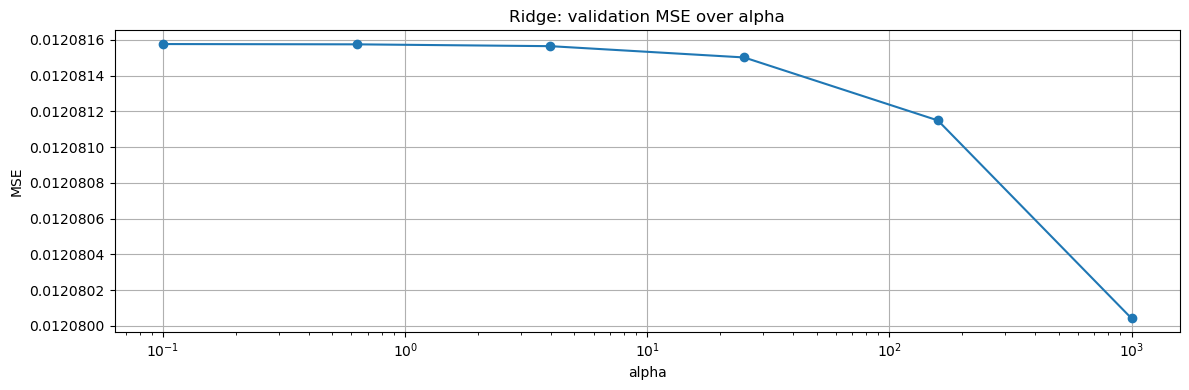

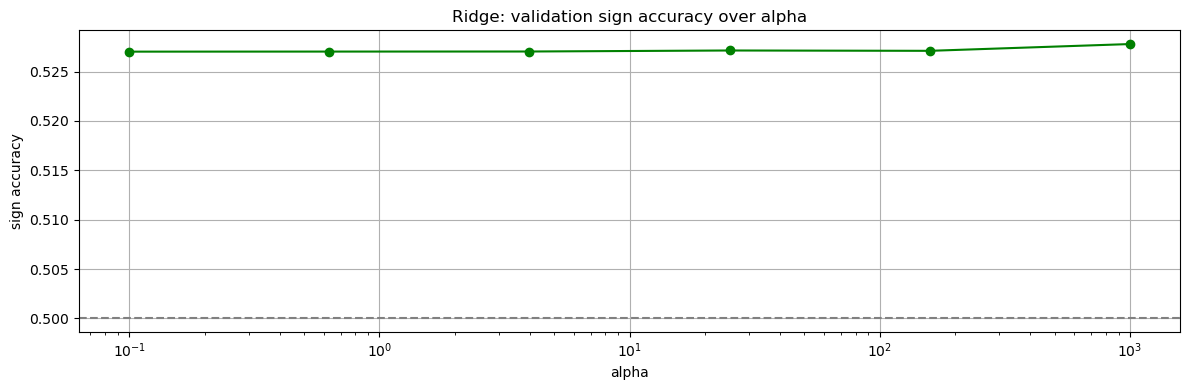

alpha grid : [1.00000000e-01 6.30957344e-01 3.98107171e+00 2.51188643e+01
 1.58489319e+02 1.00000000e+03]
mse        : [0.01208158 0.01208158 0.01208156 0.0120815  0.01208115 0.01208004]
sign acc   : [0.52702183 0.5270287  0.52703556 0.52713854 0.52710422 0.52779075]
best ridge alpha (mse+sign): 1000.0


In [98]:
# -----------------------
# tune Ridge alpha
# -----------------------
ridge_alpha_grid = np.logspace(-1, 3, 6)

ridge_mse_vals  = []
ridge_sign_vals = []

for a in tqdm(ridge_alpha_grid, desc='Tuning Ridge alpha'):
    candidate_model = Pipeline([
        ('sc', StandardScaler()),
        ('m',  Ridge(alpha=float(a), solver='svd')),
    ])
    pred = rolling_panel_forecast_val(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, candidate_model, VAL_MONTHS)
    df = pred.dropna(subset=[TARGET_COL, 'pred'])
    ridge_mse_vals.append(mse(df[TARGET_COL], df['pred']))
    ridge_sign_vals.append(sign_acc(df[TARGET_COL], df['pred']))

ridge_mse_vals  = np.array(ridge_mse_vals)
ridge_sign_vals = np.array(ridge_sign_vals)

plt.figure(figsize=(12, 4))
plt.semilogx(ridge_alpha_grid, ridge_mse_vals, marker='o')
plt.title('Ridge: validation MSE over alpha')
plt.xlabel('alpha'); plt.ylabel('MSE'); plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 4))
plt.semilogx(ridge_alpha_grid, ridge_sign_vals, marker='o', color='green')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Ridge: validation sign accuracy over alpha')
plt.xlabel('alpha'); plt.ylabel('sign accuracy'); plt.grid(True)
plt.tight_layout()
plt.show()

# pick the alpha with the best sign accuracy among the 3 alphas with lowest mse
top3 = np.argsort(ridge_mse_vals)[:3]
best_idx = top3[np.argmax(ridge_sign_vals[top3])]
best_ridge_alpha = float(ridge_alpha_grid[best_idx])

print('alpha grid :', ridge_alpha_grid)
print('mse        :', ridge_mse_vals)
print('sign acc   :', ridge_sign_vals)
print('best ridge alpha (mse+sign):', best_ridge_alpha)

#finally choose the best alpha to be our model used following
ridge = Pipeline([
    ('sc', StandardScaler()),
    ('m',  Ridge(alpha=best_ridge_alpha, solver='svd')),
])

Tuning Lasso alpha: 100%|██████████| 6/6 [11:32<00:00, 115.46s/it]


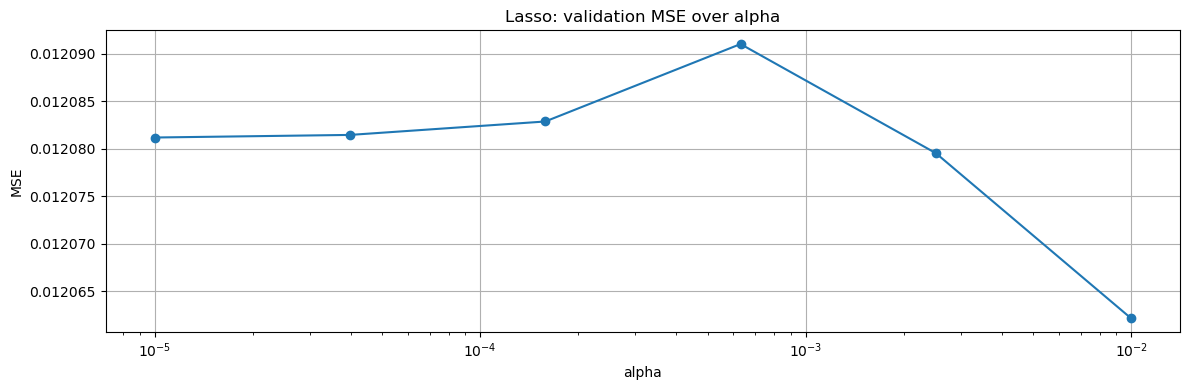

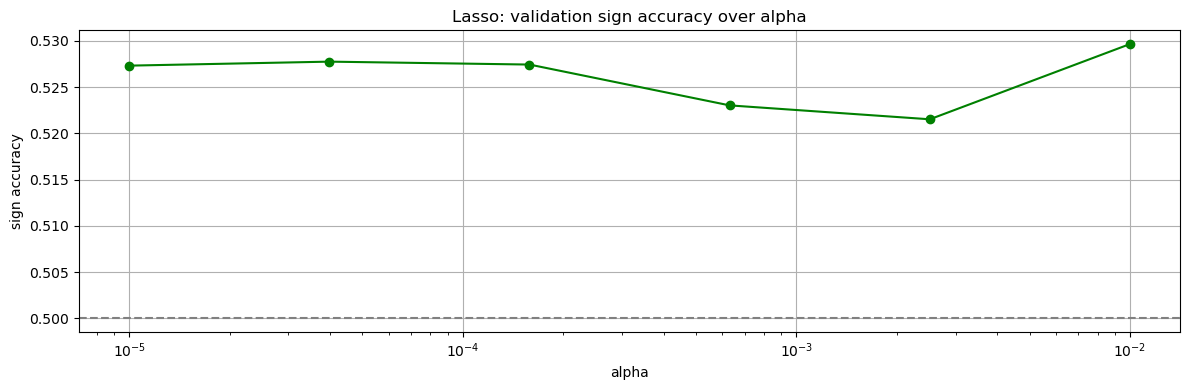

alpha grid            : [1.00000000e-05 3.98107171e-05 1.58489319e-04 6.30957344e-04
 2.51188643e-03 1.00000000e-02]
mse                   : [0.0120812  0.01208147 0.01208288 0.01209104 0.01207955 0.01206215]
sign acc              : [0.52733077 0.52776328 0.52744748 0.52303309 0.52152959 0.52966497]
within-month pred std : [0.00755352 0.00735588 0.00677923 0.00514578 0.00157607 0.        ]
usable (std > 1e-06)  : [ True  True  True  True  True False]
best lasso alpha (mse+sign, excluding degenerate alphas): 3.9810717055349695e-05


In [ ]:
# -----------------------
# tune Lasso alpha
# -----------------------
lasso_alpha_grid = np.logspace(-5, -2, 6)

lasso_mse_vals  = []
lasso_sign_vals = []
lasso_within_month_std = []  # avg cross-sectional std of 'pred' within a month, across all val months

for a in tqdm(lasso_alpha_grid, desc='Tuning Lasso alpha'):
    candidate_model = Pipeline([
        ('sc', StandardScaler()),
        ('m',  Lasso(alpha=float(a), max_iter=50000)),
    ])
    pred = rolling_panel_forecast_val(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, candidate_model, VAL_MONTHS)
    df = pred.dropna(subset=[TARGET_COL, 'pred'])
    lasso_mse_vals.append(mse(df[TARGET_COL], df['pred']))
    lasso_sign_vals.append(sign_acc(df[TARGET_COL], df['pred']))
    lasso_within_month_std.append(df.groupby(DATE_COL)['pred'].std().mean())

lasso_mse_vals  = np.array(lasso_mse_vals)
lasso_sign_vals = np.array(lasso_sign_vals)
lasso_within_month_std = np.array(lasso_within_month_std)

plt.figure(figsize=(12, 4))
plt.semilogx(lasso_alpha_grid, lasso_mse_vals, marker='o')
plt.title('Lasso: validation MSE over alpha')
plt.xlabel('alpha'); plt.ylabel('MSE'); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.semilogx(lasso_alpha_grid, lasso_sign_vals, marker='o', color='green')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Lasso: validation sign accuracy over alpha')
plt.xlabel('alpha'); plt.ylabel('sign accuracy'); plt.grid(True)
plt.tight_layout()
plt.show()

'''
At strong enough regularization, Lasso can shrink every coefficient to exactly 0, so the model degenerates to "predict the same intercept for every stock every month". That can still score well on MSE (predicting close to the mean is "safe" when the signal is weak). So we first drop any alpha whose predictions have collapsed (near-zero within-month std),then apply the same "best sign accuracy among the 3 lowest MSE" rule as before only to the alphas that still have real cross-sectional discriminating power.
'''
MIN_WITHIN_MONTH_STD = 1e-6
usable = lasso_within_month_std > MIN_WITHIN_MONTH_STD
if not usable.any():
    raise ValueError('every Lasso alpha candidate collapsed to a near-constant prediction')

usable_idx = np.flatnonzero(usable)
top3 = usable_idx[np.argsort(lasso_mse_vals[usable_idx])[:3]]
best_idx = top3[np.argmax(lasso_sign_vals[top3])]
best_lasso_alpha = float(lasso_alpha_grid[best_idx])

print('alpha grid            :', lasso_alpha_grid)
print('mse                   :', lasso_mse_vals)
print('sign acc              :', lasso_sign_vals)
print('within-month pred std :', lasso_within_month_std)
print(f'usable (std > {MIN_WITHIN_MONTH_STD:.0e})  :', usable)
print('best lasso alpha (mse+sign, excluding degenerate alphas):', best_lasso_alpha)

#as before, choose the best alpha as our model 
lasso = Pipeline([
    ('sc', StandardScaler()),
    ('m',  Lasso(alpha=best_lasso_alpha, max_iter=50000)),
])

In [100]:
#predict OLS, only on the test period (skip the validation months used to tune ridge/lasso)
pred_ols = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, ols, start_i=TEST_START_I)
print('OLS done.  shape:', pred_ols.shape)
print(pred_ols.head())

Rolling forecast: 100%|██████████| 348/348 [03:26<00:00,  1.68it/s]

OLS done.  shape: (769767, 5)
   permno   mthcaldt         y       size      pred
0   10025 1997-01-31  0.023802  12.845300  0.003442
1   10064 1997-01-31 -0.047053  12.922002  0.023051
2   10071 1997-01-31  0.092198  14.053348 -0.009631
3   10075 1997-01-31  0.004674  12.626220 -0.010271
4   10078 1997-01-31 -0.032059  16.273960 -0.001368


In [101]:
#predict by RIDGE, only on the test period
pred_ridge = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, ridge, start_i=TEST_START_I)
print('Ridge done.  shape:', pred_ridge.shape)
print(pred_ridge.head())

Rolling forecast: 100%|██████████| 348/348 [05:54<00:00,  1.02s/it]

Ridge done.  shape: (769767, 5)
   permno   mthcaldt         y       size      pred
0   10025 1997-01-31  0.023802  12.845300  0.001424
1   10064 1997-01-31 -0.047053  12.922002  0.021726
2   10071 1997-01-31  0.092198  14.053348 -0.008231
3   10075 1997-01-31  0.004674  12.626220 -0.010230
4   10078 1997-01-31 -0.032059  16.273960 -0.001177


In [102]:
#predict by LASSO, only on the test period
pred_lasso = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, lasso, start_i=TEST_START_I)
print('Lasso done.  shape:', pred_lasso.shape)
print(pred_lasso.head())

Rolling forecast: 100%|██████████| 348/348 [22:45<00:00,  3.92s/it]

Lasso done.  shape: (769767, 5)
   permno   mthcaldt         y       size      pred
0   10025 1997-01-31  0.023802  12.845300  0.000689
1   10064 1997-01-31 -0.047053  12.922002  0.020955
2   10071 1997-01-31  0.092198  14.053348 -0.007707
3   10075 1997-01-31  0.004674  12.626220 -0.010020
4   10078 1997-01-31 -0.032059  16.273960 -0.001383


In [103]:
# ── Statistical evaluation ─────────────────────────────────────────────────
def evaluate_regression(pred_df, name):
    df  = pred_df.dropna(subset=['y', 'pred'])
    m   = mse(df['y'], df['pred']) #defined before as helper func
    r2  = r2_oos(df['y'], df['pred'])#defined before as helper func
    print(f'{name:10s}  MSE: {m:.6f}   R2_oos: {r2:+.4f}   n: {len(df):,}')
    return {'MSE': round(m, 8), 'R2_oos': round(r2, 4)}

stats = {}
stats['OLS']   = evaluate_regression(pred_ols,   'OLS')
stats['Ridge'] = evaluate_regression(pred_ridge, 'Ridge')
stats['Lasso'] = evaluate_regression(pred_lasso, 'Lasso')

OLS         MSE: 0.020974   R2_oos: -0.0140   n: 766,129
Ridge       MSE: 0.021008   R2_oos: -0.0156   n: 766,129
Lasso       MSE: 0.021000   R2_oos: -0.0152   n: 766,129


In [104]:
# ── Backtest ───────────────────────────────────────────────────────────────
bt_ols   = panel_backtest(pred_ols,   date_col=DATE_COL, n_deciles=N_DECILES)
bt_ridge = panel_backtest(pred_ridge, date_col=DATE_COL, n_deciles=N_DECILES)
bt_lasso = panel_backtest(pred_lasso, date_col=DATE_COL, n_deciles=N_DECILES)

metrics_ols   = backtest_metrics(bt_ols)
metrics_ridge = backtest_metrics(bt_ridge)
metrics_lasso = backtest_metrics(bt_lasso)

print('OLS   :', metrics_ols)
print('Ridge :', metrics_ridge)
print('Lasso :', metrics_lasso)

OLS   : {'Sharpe (annual)': 0.045, 'Volatility (annual)': 0.1853, 'Cumulative return': -0.223, 'Max drawdown': -0.609, 'Average monthly ret': 0.0007}
Ridge : {'Sharpe (annual)': -0.09, 'Volatility (annual)': 0.1785, 'Cumulative return': -0.594, 'Max drawdown': -0.72, 'Average monthly ret': -0.00133}
Lasso : {'Sharpe (annual)': -0.102, 'Volatility (annual)': 0.1804, 'Cumulative return': -0.625, 'Max drawdown': -0.73, 'Average monthly ret': -0.00154}


In [105]:
# ── Summary table ──────────────────────────────────────────────────────────
summary_g1 = pd.DataFrame({
    'OLS':   {**stats['OLS'],   **metrics_ols},
    'Ridge': {**stats['Ridge'], **metrics_ridge},
    'Lasso': {**stats['Lasso'], **metrics_lasso},
}).T

print('=== Group 1 Summary: OLS / Ridge / Lasso ===')
print(summary_g1.to_string())
print()

=== Group 1 Summary: OLS / Ridge / Lasso ===
            MSE  R2_oos  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret
OLS    0.020974 -0.0140            0.045               0.1853             -0.223        -0.609              0.00070
Ridge  0.021008 -0.0156           -0.090               0.1785             -0.594        -0.720             -0.00133
Lasso  0.021000 -0.0152           -0.102               0.1804             -0.625        -0.730             -0.00154



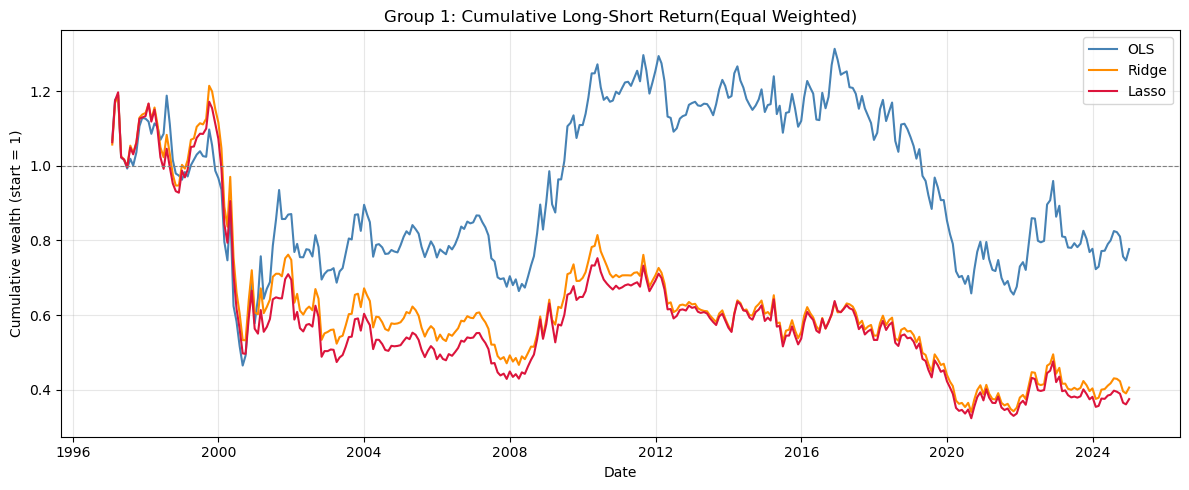

In [106]:
# ── Cumulative L-S return plot ──────────────────────────────────────────────
cum_ols   = (1 + bt_ols['ls_ret'].dropna()).cumprod()
cum_ridge = (1 + bt_ridge['ls_ret'].dropna()).cumprod()
cum_lasso = (1 + bt_lasso['ls_ret'].dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cum_ols.index,   cum_ols.values,   label='OLS',   color='steelblue',  linewidth=1.5)
plt.plot(cum_ridge.index, cum_ridge.values, label='Ridge', color='darkorange', linewidth=1.5)
plt.plot(cum_lasso.index, cum_lasso.values, label='Lasso', color='crimson',    linewidth=1.5)
plt.axhline(1.0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Group 1: Cumulative Long-Short Return(Equal Weighted)')
plt.ylabel('Cumulative wealth (start = 1)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'group1_cumret.png'), dpi=150, bbox_inches='tight')
plt.show()

In [107]:
summary_g1.to_csv(os.path.join(OUT_DIR, 'metrics_group1.csv'))
print('Metrics saved to', os.path.join(OUT_DIR, 'metrics_group1.csv'))

Metrics saved to ./output/hxz/metrics_group1.csv


## 4. Group 2 — PCR / PLS

Here we want to implement PCA and PLS to decrease dimensions of features, to reduce more noise in X. 

PCA and PLS are a bit different which is because PCA cares about X only but PLS also consider y.

`n_components` for both is tuned the same way Ridge/Lasso's alpha was tuned above: walk-forward
validation over `VAL_MONTHS` months (the same validation period, never touched by the actual
backtest), picking the component count with the best sign accuracy among the few with lowest MSE.

Tuning PCR n_components: 100%|██████████| 6/6 [02:24<00:00, 24.12s/it]


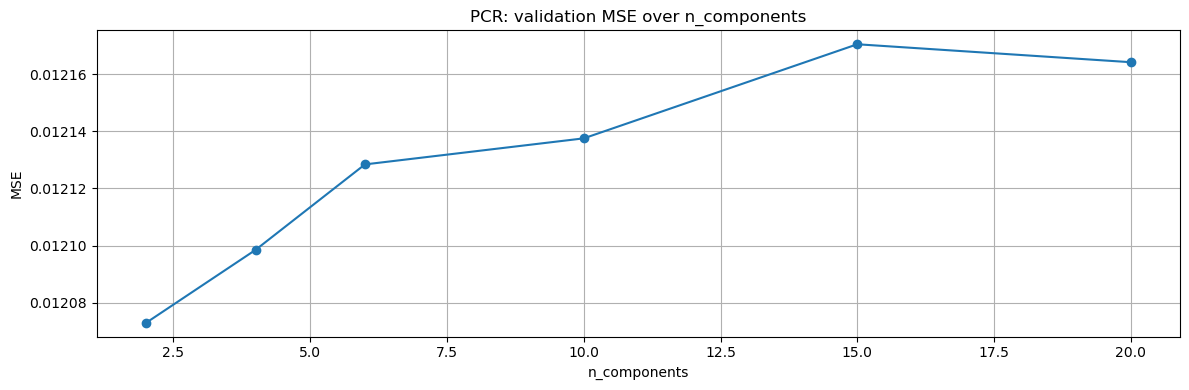

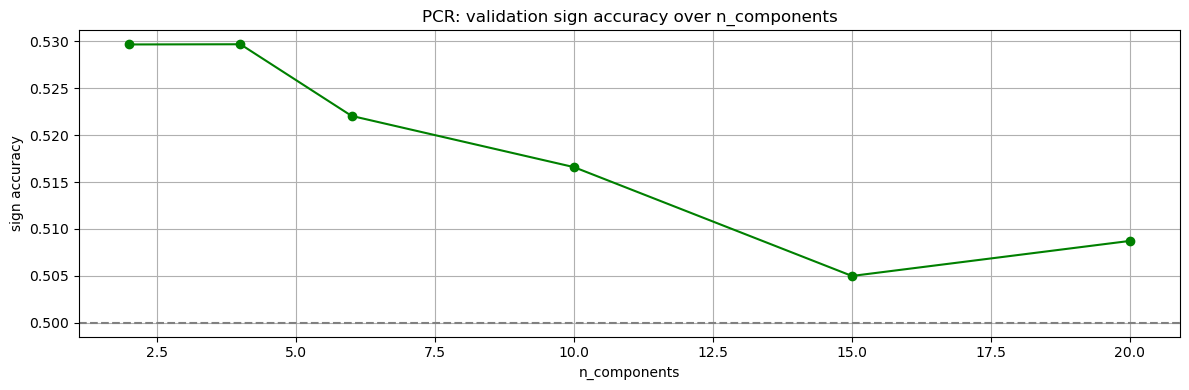

PCR n_components grid: [2, 4, 6, 10, 15, 20]
mse        : [0.01207299 0.01209848 0.01212838 0.01213749 0.0121704  0.01216413]
sign acc   : [0.52965811 0.5296787  0.52204449 0.51658657 0.50499108 0.5087258 ]
best PCR n_components (mse+sign): 4


Tuning PLS n_components: 100%|██████████| 6/6 [04:17<00:00, 42.89s/it]


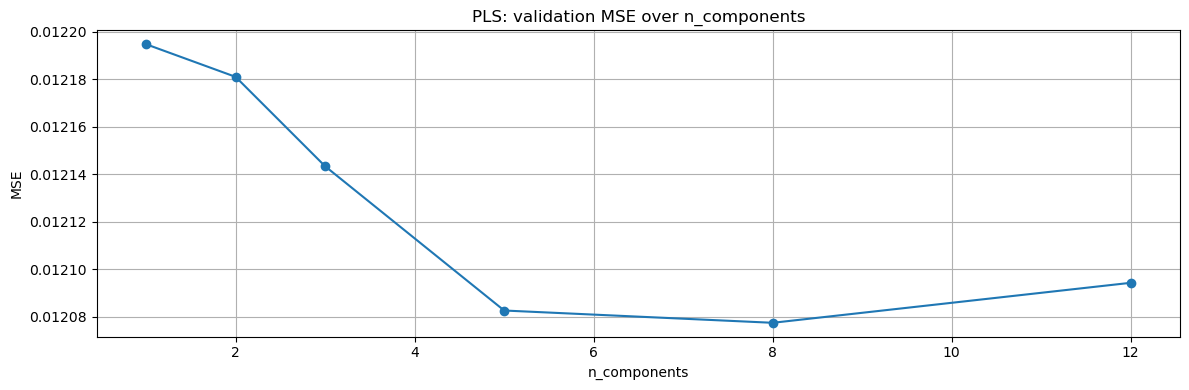

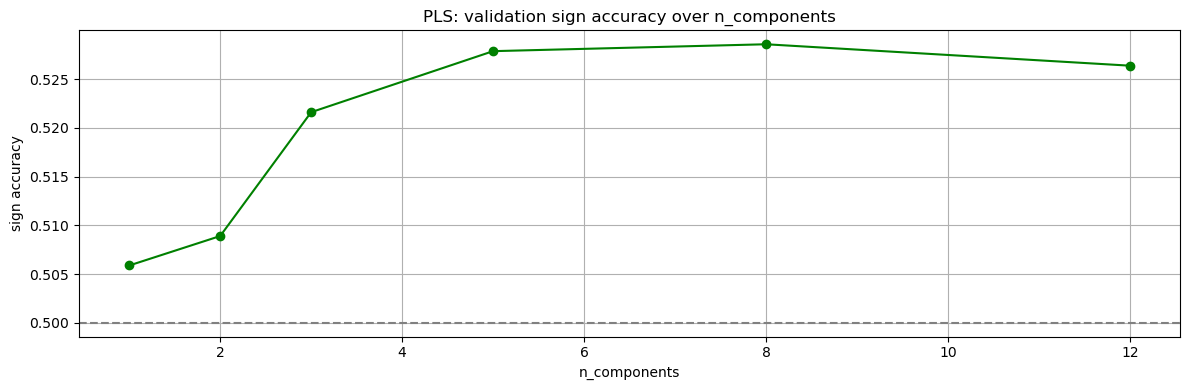

PLS n_components grid: [1, 2, 3, 5, 8, 12]
mse        : [0.01219476 0.01218101 0.01214334 0.01208255 0.01207738 0.01209423]
sign acc   : [0.5058767  0.50889743 0.52159824 0.5278594  0.52856652 0.52636963]
best PLS n_components (mse+sign): 8


In [109]:
# -----------------------
# tune PCR's and PLS's n_components (same walk-forward validation as Ridge/Lasso above)
# -----------------------
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

pcr_k_grid = [2, 4, 6, 10, 15, 20]
pls_k_grid = [1, 2, 3, 5, 8, 12]

pcr_mse_vals, pcr_sign_vals = [], []
for k in tqdm(pcr_k_grid, desc='Tuning PCR n_components'):
    candidate_model = Pipeline([
        ('sc',  StandardScaler()),
        ('pca', PCA(n_components=k)),
        ('m',   LinearRegression()),
    ])
    pred = rolling_panel_forecast_val(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, candidate_model, VAL_MONTHS)
    df = pred.dropna(subset=[TARGET_COL, 'pred'])
    pcr_mse_vals.append(mse(df[TARGET_COL], df['pred']))
    pcr_sign_vals.append(sign_acc(df[TARGET_COL], df['pred']))

pcr_mse_vals  = np.array(pcr_mse_vals)
pcr_sign_vals = np.array(pcr_sign_vals)

plt.figure(figsize=(12, 4))
plt.plot(pcr_k_grid, pcr_mse_vals, marker='o')
plt.title('PCR: validation MSE over n_components')
plt.xlabel('n_components'); plt.ylabel('MSE'); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(pcr_k_grid, pcr_sign_vals, marker='o', color='green')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('PCR: validation sign accuracy over n_components')
plt.xlabel('n_components'); plt.ylabel('sign accuracy'); plt.grid(True)
plt.tight_layout()
plt.show()

# same rule as Ridge/Lasso: best sign accuracy among the 3 component-counts with lowest mse
top3 = np.argsort(pcr_mse_vals)[:3]
best_idx = top3[np.argmax(pcr_sign_vals[top3])]
PCR_N_COMPONENTS = int(pcr_k_grid[best_idx])

print('PCR n_components grid:', pcr_k_grid)
print('mse        :', pcr_mse_vals)
print('sign acc   :', pcr_sign_vals)
print('best PCR n_components (mse+sign):', PCR_N_COMPONENTS)


pls_mse_vals, pls_sign_vals = [], []
for k in tqdm(pls_k_grid, desc='Tuning PLS n_components'):
    candidate_model = Pipeline([
        ('sc', StandardScaler()),
        ('m',  PLSRegression(n_components=k)),
    ])
    pred = rolling_panel_forecast_val(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, candidate_model, VAL_MONTHS)
    df = pred.dropna(subset=[TARGET_COL, 'pred'])
    pls_mse_vals.append(mse(df[TARGET_COL], df['pred']))
    pls_sign_vals.append(sign_acc(df[TARGET_COL], df['pred']))

pls_mse_vals  = np.array(pls_mse_vals)
pls_sign_vals = np.array(pls_sign_vals)

plt.figure(figsize=(12, 4))
plt.plot(pls_k_grid, pls_mse_vals, marker='o')
plt.title('PLS: validation MSE over n_components')
plt.xlabel('n_components'); plt.ylabel('MSE'); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(pls_k_grid, pls_sign_vals, marker='o', color='green')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('PLS: validation sign accuracy over n_components')
plt.xlabel('n_components'); plt.ylabel('sign accuracy'); plt.grid(True)
plt.tight_layout()
plt.show()

top3 = np.argsort(pls_mse_vals)[:3]
best_idx = top3[np.argmax(pls_sign_vals[top3])]
PLS_N_COMPONENTS = int(pls_k_grid[best_idx])

print('PLS n_components grid:', pls_k_grid)
print('mse        :', pls_mse_vals)
print('sign acc   :', pls_sign_vals)
print('best PLS n_components (mse+sign):', PLS_N_COMPONENTS)


In [110]:
pcr = Pipeline([
    ('sc',  StandardScaler()),
    ('pca', PCA(n_components=PCR_N_COMPONENTS)),
    ('m',   LinearRegression()),
])#pcr=pca+regression

pls = Pipeline([
    ('sc', StandardScaler()),
    ('m',  PLSRegression(n_components=PLS_N_COMPONENTS)),
])

print(f'PCR n_components = {PCR_N_COMPONENTS}  (out of {len(FEATURE_COLS)} features)')
print(f'PLS n_components = {PLS_N_COMPONENTS}')

PCR n_components = 4  (out of 28 features)
PLS n_components = 8


In [111]:
pred_pcr = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, pcr, start_i=TEST_START_I)
print('PCR done.  shape:', pred_pcr.shape)
print(pred_pcr.head())

Rolling forecast: 100%|██████████| 348/348 [02:11<00:00,  2.65it/s]

PCR done.  shape: (769767, 5)
   permno   mthcaldt         y       size      pred
0   10025 1997-01-31  0.023802  12.845300  0.008809
1   10064 1997-01-31 -0.047053  12.922002  0.009199
2   10071 1997-01-31  0.092198  14.053348  0.006440
3   10075 1997-01-31  0.004674  12.626220  0.008352
4   10078 1997-01-31 -0.032059  16.273960  0.005614


In [112]:
pred_pls = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, pls, start_i=TEST_START_I)
print('PLS done.  shape:', pred_pls.shape)
print(pred_pls.head())

Rolling forecast: 100%|██████████| 348/348 [06:57<00:00,  1.20s/it]

PLS done.  shape: (769767, 5)
   permno   mthcaldt         y       size      pred
0   10025 1997-01-31  0.023802  12.845300  0.002206
1   10064 1997-01-31 -0.047053  12.922002  0.022314
2   10071 1997-01-31  0.092198  14.053348 -0.009642
3   10075 1997-01-31  0.004674  12.626220 -0.009939
4   10078 1997-01-31 -0.032059  16.273960 -0.001965


In [113]:
stats['PCR'] = evaluate_regression(pred_pcr, 'PCR')
stats['PLS'] = evaluate_regression(pred_pls, 'PLS')

bt_pcr = panel_backtest(pred_pcr, date_col=DATE_COL, n_deciles=N_DECILES)
bt_pls = panel_backtest(pred_pls, date_col=DATE_COL, n_deciles=N_DECILES)

metrics_pcr = backtest_metrics(bt_pcr)
metrics_pls = backtest_metrics(bt_pls)

print('PCR backtest:', metrics_pcr)
print('PLS backtest:', metrics_pls)
print()

PCR         MSE: 0.020734   R2_oos: -0.0024   n: 766,129
PLS         MSE: 0.020980   R2_oos: -0.0143   n: 766,129
PCR backtest: {'Sharpe (annual)': -0.065, 'Volatility (annual)': 0.3003, 'Cumulative return': -0.842, 'Max drawdown': -0.894, 'Average monthly ret': -0.00164}
PLS backtest: {'Sharpe (annual)': -0.02, 'Volatility (annual)': 0.18, 'Cumulative return': -0.43, 'Max drawdown': -0.623, 'Average monthly ret': -0.00031}



In [114]:
summary_g2 = pd.DataFrame({
    'PCR': {**stats['PCR'], **metrics_pcr},
    'PLS': {**stats['PLS'], **metrics_pls},
}).T


summary_g2.to_csv(os.path.join(OUT_DIR, 'metrics_group2.csv'))

print('=== Group 2 Summary: PCR / PLS ===')
print(summary_g2.to_string())

=== Group 2 Summary: PCR / PLS ===
          MSE  R2_oos  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret
PCR  0.020734 -0.0024           -0.065               0.3003             -0.842        -0.894             -0.00164
PLS  0.020980 -0.0143           -0.020               0.1800             -0.430        -0.623             -0.00031


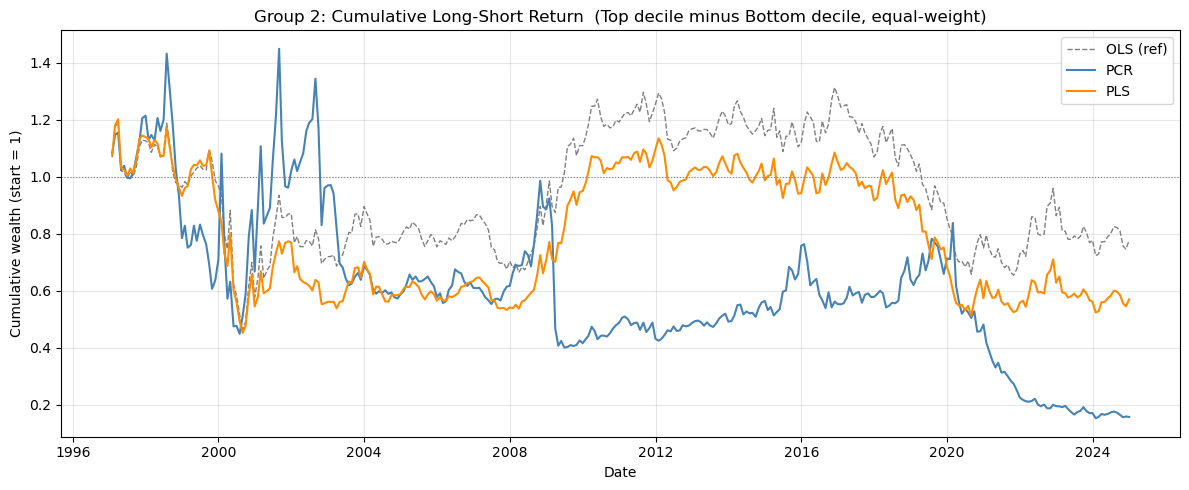

In [115]:
cum_pcr = (1 + bt_pcr['ls_ret'].dropna()).cumprod()
cum_pls = (1 + bt_pls['ls_ret'].dropna()).cumprod()

# recall OLS as benchmark
bt_ols_ref = panel_backtest(pred_ols, date_col=DATE_COL, n_deciles=N_DECILES)
cum_ols_ref = (1 + bt_ols_ref['ls_ret'].dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cum_ols_ref.index, cum_ols_ref.values, label='OLS (ref)', color='gray',       linewidth=1.0, linestyle='--')
plt.plot(cum_pcr.index,     cum_pcr.values,     label='PCR',       color='steelblue',  linewidth=1.5)
plt.plot(cum_pls.index,     cum_pls.values,     label='PLS',       color='darkorange', linewidth=1.5)
plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
plt.title('Group 2: Cumulative Long-Short Return  (Top decile minus Bottom decile, equal-weight)')
plt.ylabel('Cumulative wealth (start = 1)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'group2_cumret.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Group 3 — Decision Tree (Regressor)

Single regression tree. `max_depth` is tuned the same way as Ridge/Lasso's alpha and PCR/PLS's
n_components above: walk-forward validation over `VAL_MONTHS` months, picking the depth with the
best sign accuracy among the few with lowest MSE. Shallow depth is expected to win, since it
prevents overfitting on the ~500K-row training windows.

Tuning Tree max_depth: 100%|██████████| 6/6 [33:40<00:00, 336.68s/it]


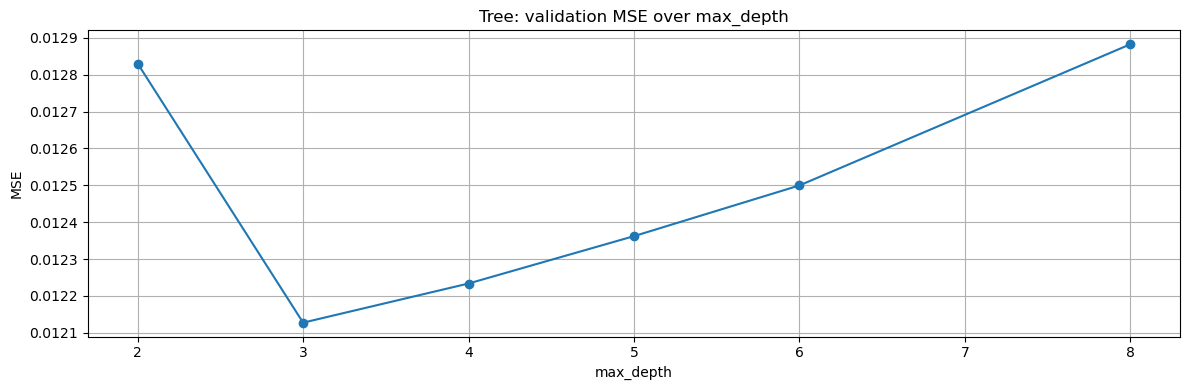

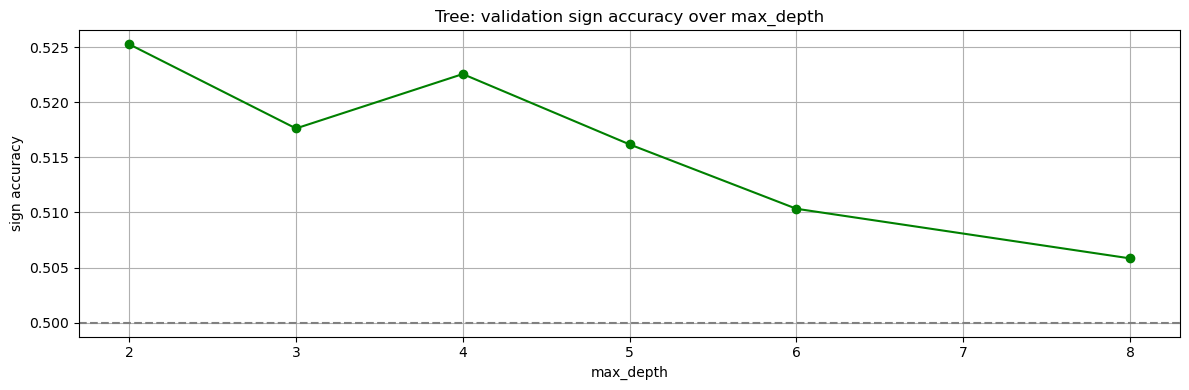

max_depth grid: [2, 3, 4, 5, 6, 8]
mse        : [0.01283024 0.01212755 0.01223375 0.01236221 0.01249972 0.01288255]
sign acc   : [0.52527118 0.5176301  0.52256625 0.51618152 0.51033915 0.50583551]
best Tree max_depth (mse+sign): 4


In [117]:
# -----------------------
# tune Tree's max_depth (same walk-forward validation as Ridge/Lasso/PCR/PLS above)
# -----------------------
from sklearn.tree import DecisionTreeRegressor

tree_depth_grid = [2, 3, 4, 5, 6, 8]
tree_mse_vals, tree_sign_vals = [], []

for d in tqdm(tree_depth_grid, desc='Tuning Tree max_depth'):
    candidate_model = Pipeline([
        ('sc', StandardScaler()),
        ('m',  DecisionTreeRegressor(max_depth=d, random_state=RANDOM_SEED)),
    ])
    pred = rolling_panel_forecast_val(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, candidate_model, VAL_MONTHS)
    df = pred.dropna(subset=[TARGET_COL, 'pred'])
    tree_mse_vals.append(mse(df[TARGET_COL], df['pred']))
    tree_sign_vals.append(sign_acc(df[TARGET_COL], df['pred']))

tree_mse_vals  = np.array(tree_mse_vals)
tree_sign_vals = np.array(tree_sign_vals)

plt.figure(figsize=(12, 4))
plt.plot(tree_depth_grid, tree_mse_vals, marker='o')
plt.title('Tree: validation MSE over max_depth')
plt.xlabel('max_depth'); plt.ylabel('MSE'); plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(tree_depth_grid, tree_sign_vals, marker='o', color='green')
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Tree: validation sign accuracy over max_depth')
plt.xlabel('max_depth'); plt.ylabel('sign accuracy'); plt.grid(True)
plt.tight_layout()
plt.show()

# same rule as Ridge/Lasso/PCR/PLS: best sign accuracy among the 3 depths with lowest mse
top3 = np.argsort(tree_mse_vals)[:3]
best_idx = top3[np.argmax(tree_sign_vals[top3])]
best_tree_max_depth = int(tree_depth_grid[best_idx])

print('max_depth grid:', tree_depth_grid)
print('mse        :', tree_mse_vals)
print('sign acc   :', tree_sign_vals)
print('best Tree max_depth (mse+sign):', best_tree_max_depth)


In [118]:
tree = Pipeline([
    ('sc', StandardScaler()),
    ('m',  DecisionTreeRegressor(max_depth=best_tree_max_depth, random_state=RANDOM_SEED)),
])

pred_tree = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, tree, start_i=TEST_START_I)
print('Tree done.  shape:', pred_tree.shape)
print(pred_tree.head())

Rolling forecast: 100%|██████████| 348/348 [44:24<00:00,  7.66s/it]

Tree done.  shape: (769767, 5)
   permno   mthcaldt         y       size      pred
0   10025 1997-01-31  0.023802  12.845300  0.009353
1   10064 1997-01-31 -0.047053  12.922002  0.009353
2   10071 1997-01-31  0.092198  14.053348  0.009353
3   10075 1997-01-31  0.004674  12.626220  0.009353
4   10078 1997-01-31 -0.032059  16.273960  0.009353


In [119]:
#backtest of tree
stats['Tree'] = evaluate_regression(pred_tree, 'Tree')
bt_tree = panel_backtest(pred_tree, date_col=DATE_COL, n_deciles=N_DECILES)
metrics_tree  = backtest_metrics(bt_tree)
print('Tree backtest:', metrics_tree)

summary_g3 = pd.DataFrame({'Tree': {**stats['Tree'], **metrics_tree}}).T
print(summary_g3.to_string())

summary_g3.to_csv(os.path.join(OUT_DIR, 'metrics_group3.csv'))

Tree        MSE: 0.022103   R2_oos: -0.0686   n: 766,129
Tree backtest: {'Sharpe (annual)': 0.16, 'Volatility (annual)': 0.2371, 'Cumulative return': 0.094, 'Max drawdown': -0.289, 'Average monthly ret': 0.00316}
           MSE  R2_oos  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret
Tree  0.022103 -0.0686             0.16               0.2371              0.094        -0.289              0.00316


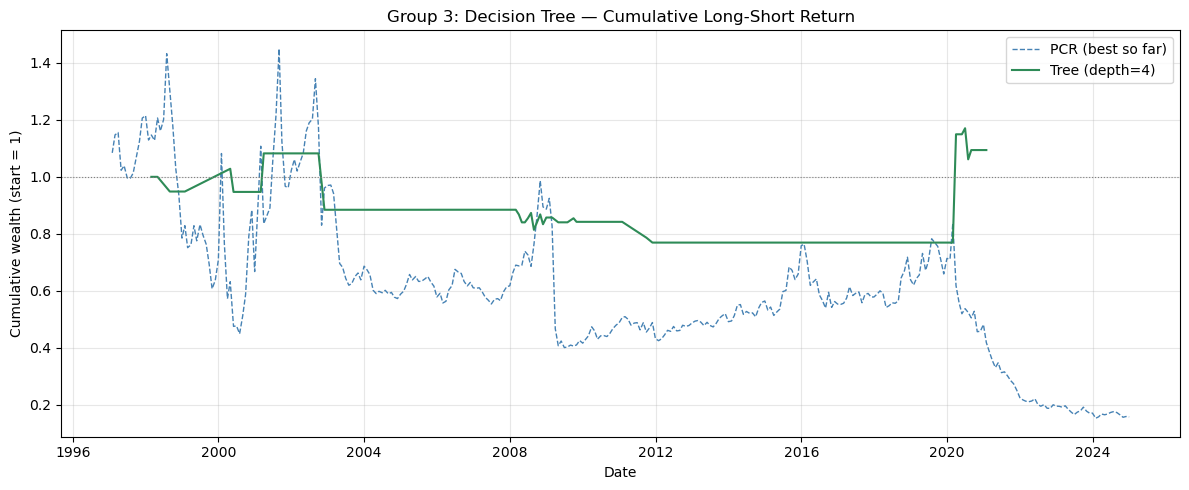

In [120]:
#visulization of tree model's backtest
cum_tree = (1 + bt_tree['ls_ret'].dropna()).cumprod()
cum_pcr  = (1 + bt_pcr['ls_ret'].dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cum_pcr.index,  cum_pcr.values,  label='PCR (best so far)', color='steelblue', linewidth=1.0, linestyle='--')
plt.plot(cum_tree.index, cum_tree.values, label='Tree (depth=4)',    color='seagreen',  linewidth=1.5)
plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
plt.title('Group 3: Decision Tree — Cumulative Long-Short Return')
plt.ylabel('Cumulative wealth (start = 1)')
plt.xlabel('Date')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'group3_cumret.png'), dpi=150, bbox_inches='tight')
plt.show()



## 6. Group 3b — Ensemble Trees (Random Forest / Bagging / Boosting)

Since `RANDOM FOREST` and `BAGGING` both use bootstrap to fit each tree, as we derived in the lectures, there will be around 37% of the sample which is not used in training. Naturally this part can be used for tunning. Using OOB score to pick the number of trees (`n_estimators`) for both.

For Boosting we use `HistGradientBoostingRegressor` instead of the plain `GradientBoostingRegressor`. Both implement the same gradient boosting idea, but `HistGradientBoostingRegressor` bins each feature into histograms before splitting, which is dramatically faster to fit on our ~500K-row training windows — this matters a lot since the rolling forecast refits it many times. It does not bootstrap rows like RF/Bagging, but has its own built-in early stopping: it holds out a validation slice of the training window and stops adding boosting rounds once `n_iter_no_change` rounds pass without an improvement in validation score (`validation_score_`), which we use the same way RF/Bagging use OOB score to decide how many rounds to keep.

Unlike before, here we do not need extra validation period, since we can tune our models just by using training periods.

/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


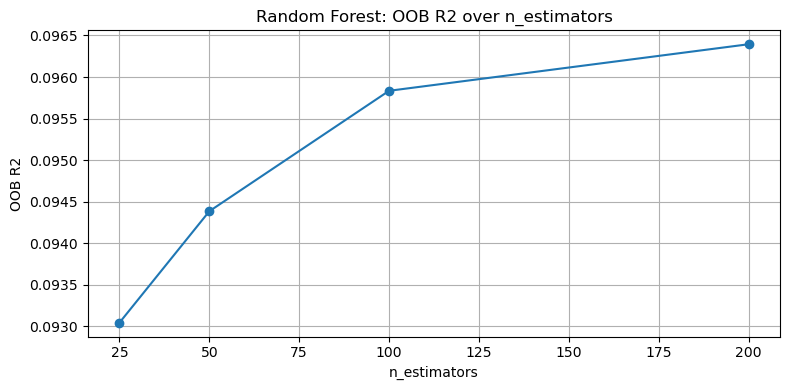

n_estimators grid: [25, 50, 100, 200]
OOB R2           : [0.09304255848747589, 0.09438421685961729, 0.09583413801707996, 0.09639450238126279]
best n_estimators (RF, smallest within 5% of best OOB R2): 25


In [122]:
# -----------------------
# pick n_estimators for Random Forest using OOB score
# -----------------------
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, HistGradientBoostingRegressor

def smallest_n_within_tol(n_grid, scores, acceptable_drop_pct=0.05):
    # OOB score usually stops improving way before the grid's biggest n_estimators.
    # instead of always taking the highest score, take the smallest n_estimators whose
    # score is still within acceptable_drop_pct of the best one. much cheaper to refit
    # every month in the rolling forecast, for basically the same OOB performance.
    best_score = max(scores)
    threshold = best_score - abs(best_score) * acceptable_drop_pct
    for n, s in zip(n_grid, scores):
        if s >= threshold:
            return n
    return n_grid[int(np.argmax(scores))]


n_estimators_grid = [25, 50, 100, 200]  # halved to reduce peak memory on an 8GB machine
rf_oob_scores = []

for n in n_estimators_grid:
    candidate_model = RandomForestRegressor(n_estimators=n, max_depth=5, oob_score=True,
                                             random_state=RANDOM_SEED, n_jobs=2)
    candidate_model.fit(X_tune[FEATURE_COLS], X_tune[TARGET_COL])  # fixed: no look-ahead, see cell above
    rf_oob_scores.append(candidate_model.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_grid, rf_oob_scores, marker='o')
plt.title('Random Forest: OOB R2 over n_estimators')
plt.xlabel('n_estimators'); plt.ylabel('OOB R2'); plt.grid(True)
plt.tight_layout()
plt.show()

best_n_rf = smallest_n_within_tol(n_estimators_grid, rf_oob_scores, acceptable_drop_pct=0.05)
print('n_estimators grid:', n_estimators_grid)
print('OOB R2           :', rf_oob_scores)
print('best n_estimators (RF, smallest within 5% of best OOB R2):', best_n_rf)

rf = Pipeline([
    ('sc', StandardScaler()),
    ('m',  RandomForestRegressor(n_estimators=best_n_rf, max_depth=5,
                                  random_state=RANDOM_SEED, n_jobs=2)),
])

/opt/miniconda3/lib/python3.12/site-packages/sklearn/ensemble/_bagging.py:1526: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(


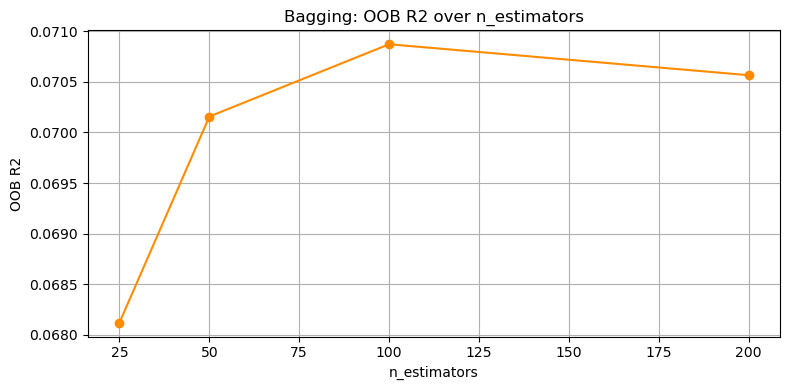

n_estimators grid: [25, 50, 100, 200]
OOB R2           : [0.06812158092454146, 0.0701559092044719, 0.07086945157152869, 0.07056403244603271]
best n_estimators (Bagging, smallest within 5% of best OOB R2): 25


In [123]:
# -----------------------
# pick n_estimators for Bagging using OOB score
# -----------------------
bag_oob_scores = []
for n in n_estimators_grid:
    candidate_model = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=n,
                                        oob_score=True, random_state=RANDOM_SEED, n_jobs=2)
    candidate_model.fit(X_tune[FEATURE_COLS], X_tune[TARGET_COL])  # fixed: no look-ahead, see cell above
    bag_oob_scores.append(candidate_model.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_estimators_grid, bag_oob_scores, marker='o', color='darkorange')
plt.title('Bagging: OOB R2 over n_estimators')
plt.xlabel('n_estimators'); plt.ylabel('OOB R2'); plt.grid(True)
plt.tight_layout()
plt.show()

best_n_bag = smallest_n_within_tol(n_estimators_grid, bag_oob_scores, acceptable_drop_pct=0.05)
print('n_estimators grid:', n_estimators_grid)
print('OOB R2           :', bag_oob_scores)
print('best n_estimators (Bagging, smallest within 5% of best OOB R2):', best_n_bag)

bagging = Pipeline([
    ('sc', StandardScaler()),
    ('m',  BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=4), n_estimators=best_n_bag,
                             random_state=RANDOM_SEED, n_jobs=2)),
])

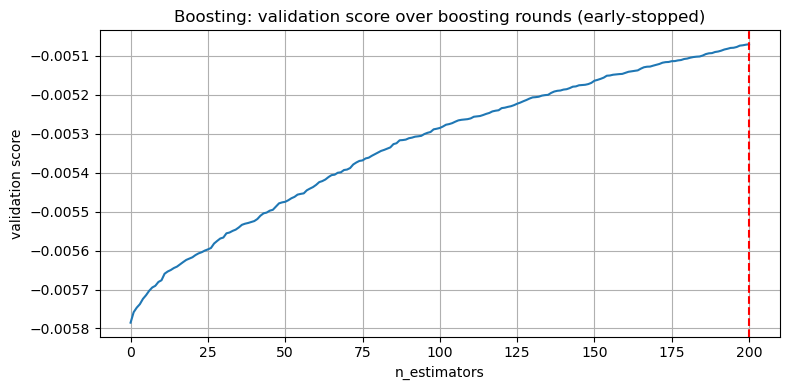

best n_estimators (Boosting, chosen by early stopping): 200


In [124]:
# -----------------------
# pick n_estimators for Boosting using HistGradientBoostingRegressor's built-in early stopping
# -----------------------
gb_search = HistGradientBoostingRegressor(max_iter=max(n_estimators_grid), max_depth=3,
                                           learning_rate=0.05, early_stopping=True,
                                           validation_fraction=0.1, n_iter_no_change=10,
                                           random_state=RANDOM_SEED)
gb_search.fit(X_tune[FEATURE_COLS], X_tune[TARGET_COL])  # fixed: no look-ahead, see cell above

# unlike RF/Bagging, no need to loop over n_estimators_grid by hand: early_stopping=True
# already stopped adding rounds once validation_score_ stopped improving
val_scores = gb_search.validation_score_
best_n_gb  = gb_search.n_iter_

plt.figure(figsize=(8, 4))
plt.plot(val_scores)
plt.axvline(best_n_gb, color='red', linestyle='--')
plt.title('Boosting: validation score over boosting rounds (early-stopped)')
plt.xlabel('n_estimators'); plt.ylabel('validation score'); plt.grid(True)
plt.tight_layout()
plt.show()

print('best n_estimators (Boosting, chosen by early stopping):', best_n_gb)

boosting = Pipeline([
    ('sc', StandardScaler()),
    ('m',  HistGradientBoostingRegressor(max_iter=best_n_gb, max_depth=3, learning_rate=0.05,
                                          random_state=RANDOM_SEED)),
])

In [125]:
#predict by ensembles, only on the test period
#refitting RF/Bagging/Boosting every single month is way too slow (hundreds of trees x 348
#months). instead we only refit every REFIT_EVERY months and reuse that model in between,
#trees don't really change that much month to month anyway.
REFIT_EVERY = 12  # refit once a year

pred_rf = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, rf,
                                  start_i=TEST_START_I, refit_every=REFIT_EVERY)
print('RF done.  shape:', pred_rf.shape)
import gc; gc.collect()


Rolling forecast: 100%|██████████| 348/348 [36:40<00:00,  6.32s/it]


RF done.  shape: (769767, 5)


0

In [126]:
pred_bagging = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, bagging,
                                       start_i=TEST_START_I, refit_every=REFIT_EVERY)
print('Bagging done.  shape:', pred_bagging.shape)
import gc; gc.collect()


Rolling forecast: 100%|██████████| 348/348 [30:03<00:00,  5.18s/it]


Bagging done.  shape: (769767, 5)


0

In [127]:
pred_boosting = rolling_panel_forecast(panel_ml, FEATURE_COLS, TARGET_COL, DATE_COL, H, boosting,
                                        start_i=TEST_START_I, refit_every=REFIT_EVERY)
print('Boosting done.  shape:', pred_boosting.shape)
import gc; gc.collect()


Rolling forecast: 100%|██████████| 348/348 [01:36<00:00,  3.61it/s]


Boosting done.  shape: (769767, 5)


0

In [128]:
#backtest of ensembles
stats['RF']       = evaluate_regression(pred_rf,       'RF')
stats['Bagging']  = evaluate_regression(pred_bagging,  'Bagging')
stats['Boosting'] = evaluate_regression(pred_boosting, 'Boosting')

bt_rf       = panel_backtest(pred_rf, date_col=DATE_COL, n_deciles=N_DECILES)
bt_bagging  = panel_backtest(pred_bagging, date_col=DATE_COL, n_deciles=N_DECILES)
bt_boosting = panel_backtest(pred_boosting, date_col=DATE_COL, n_deciles=N_DECILES)

metrics_rf       = backtest_metrics(bt_rf)
metrics_bagging  = backtest_metrics(bt_bagging)
metrics_boosting = backtest_metrics(bt_boosting)

print('RF backtest      :', metrics_rf)
print('Bagging backtest :', metrics_bagging)
print('Boosting backtest:', metrics_boosting)

summary_g3b = pd.DataFrame({
    'RF':       {**stats['RF'],       **metrics_rf},
    'Bagging':  {**stats['Bagging'],  **metrics_bagging},
    'Boosting': {**stats['Boosting'], **metrics_boosting},
}).T
print(summary_g3b.to_string())

summary_g3b.to_csv(os.path.join(OUT_DIR, 'metrics_group3b.csv'))

RF          MSE: 0.022319   R2_oos: -0.0790   n: 766,129
Bagging     MSE: 0.022074   R2_oos: -0.0671   n: 766,129
Boosting    MSE: 0.022253   R2_oos: -0.0758   n: 766,129
RF backtest      : {'Sharpe (annual)': -0.191, 'Volatility (annual)': 0.2653, 'Cumulative return': -0.835, 'Max drawdown': -0.847, 'Average monthly ret': -0.00422}
Bagging backtest : {'Sharpe (annual)': -0.111, 'Volatility (annual)': 0.2243, 'Cumulative return': -0.447, 'Max drawdown': -0.615, 'Average monthly ret': -0.00207}
Boosting backtest: {'Sharpe (annual)': 0.105, 'Volatility (annual)': 0.2397, 'Cumulative return': -0.059, 'Max drawdown': -0.641, 'Average monthly ret': 0.0021}
               MSE  R2_oos  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret
RF        0.022319 -0.0790           -0.191               0.2653             -0.835        -0.847             -0.00422
Bagging   0.022074 -0.0671           -0.111               0.2243             -0.447        -0.615     

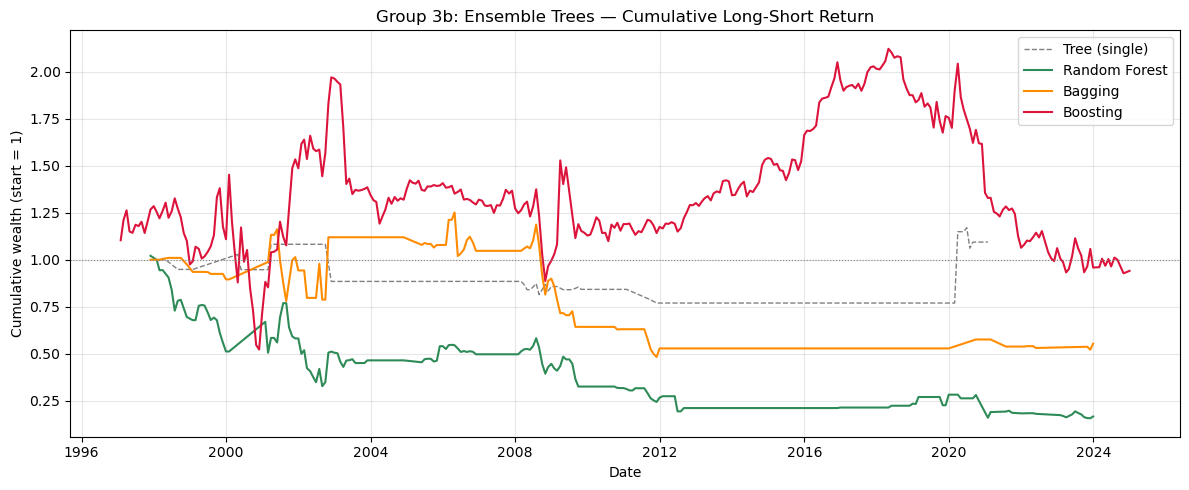

In [129]:
#visualization of ensemble models' backtest
cum_rf       = (1 + bt_rf['ls_ret'].dropna()).cumprod()
cum_bagging  = (1 + bt_bagging['ls_ret'].dropna()).cumprod()
cum_boosting = (1 + bt_boosting['ls_ret'].dropna()).cumprod()
cum_tree     = (1 + bt_tree['ls_ret'].dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cum_tree.index,     cum_tree.values,     label='Tree (single)', color='gray',       linewidth=1.0, linestyle='--')
plt.plot(cum_rf.index,       cum_rf.values,       label='Random Forest', color='seagreen',   linewidth=1.5)
plt.plot(cum_bagging.index,  cum_bagging.values,  label='Bagging',       color='darkorange', linewidth=1.5)
plt.plot(cum_boosting.index, cum_boosting.values, label='Boosting',      color='crimson',    linewidth=1.5)
plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
plt.title('Group 3b: Ensemble Trees — Cumulative Long-Short Return')
plt.ylabel('Cumulative wealth (start = 1)')
plt.xlabel('Date')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'group3b_cumret.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Group 4 — Logistic Regression

To use the classifier(Logistic Regression Model), first we need to relable the target variable. Here we set it to be 1 if `next period's excess return > next period's cross-sectional median`.

Model outputs predicted probability of being winner stock next period, stocks are ranked by that probability. Plus the predicated probability is used for backtest.

As for classifier, we cannot use MSE, so we use `Accuracy` and `AUC` instead.

Below we also add a **Multinomial Logistic Regression** (5-class, quintile split) as a richer alternative to the binary median split.

In [131]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# Construct cross-sectional binary label 
# y_bin = 1 if stock's next period's excess return > monthly cross-sectional median
panel['y_bin'] = (
    panel.groupby(DATE_COL)['y']
    .transform(lambda x: (x > x.median()).astype(float))
)
panel.loc[panel['y'].isna(), 'y_bin'] = np.nan

panel_clf = panel[['permno', DATE_COL, 'y', 'y_bin'] + FEATURE_COLS].copy()
panel_clf[FEATURE_COLS] = panel_clf[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
panel_clf[FEATURE_COLS] = panel_clf[FEATURE_COLS].astype('float32')

#check whether two types are balanced
print(f'Overall y_bin balance: {panel_clf["y_bin"].mean():.3f}')

# same idea as X_last_train, but for the classifier's panel
X_last_train_clf = panel_clf[panel_clf[DATE_COL].isin(LAST_TRAIN_MONTHS)].dropna(subset=FEATURE_COLS + ['y_bin'])

Overall y_bin balance: 0.499


In [132]:
# ── Classification rolling forecast (same logic as before) ───────────────────
def rolling_panel_forecast_clf(panel, feature_cols, target_col, date_col, h, model,
                                show_progress=True, start_i=None):
    month_starts = {}; month_ends = {}
    for month, grp in panel.groupby(date_col, sort=True):
        month_starts[month] = int(grp.index[0])
        month_ends[month]   = int(grp.index[-1]) + 1
    months = sorted(month_starts); n = len(months)

    if start_i is None:
        start_i = h

    records = []
    it = range(start_i, n)
    if show_progress:
        it = tqdm(it, total=n - start_i, desc='Rolling forecast')

    for i in it:
        row_s = month_starts[months[i - h]]; row_e = month_ends[months[i - 1]]
        pr_s  = month_starts[months[i]];     pr_e  = month_ends[months[i]]

        train = panel.iloc[row_s:row_e].dropna(subset=feature_cols + [target_col])
        pred  = panel.iloc[pr_s:pr_e].dropna(subset=feature_cols)

        if len(train) < 10 or len(pred) == 0: continue
        if train[target_col].nunique() < 2: continue  # both classes required

        model.fit(train[feature_cols].values, train[target_col].values)
        proba = model.predict_proba(pred[feature_cols].values)[:, 1]

        out = pred[['permno', date_col, 'y', target_col, 'size']].copy()  # carry 'size' through for cap-weighted backtest
        out['pred'] = proba
        records.append(out)

    if len(records) == 0:
        return pd.DataFrame()

    result = pd.concat(records, ignore_index=True)
    return result

In [133]:
logit = Pipeline([
    ('sc', StandardScaler()),
    ('m',  LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')),
])

pred_logit = rolling_panel_forecast_clf(
    panel_clf, FEATURE_COLS, 'y_bin', DATE_COL, H, logit, start_i=TEST_START_I
)
print('Logit done.  shape:', pred_logit.shape)
print(pred_logit.head())
import gc; gc.collect()


Rolling forecast: 100%|██████████| 348/348 [08:07<00:00,  1.40s/it]


Logit done.  shape: (769767, 6)
   permno   mthcaldt         y  y_bin       size      pred
0   10025 1997-01-31  0.023802    1.0  12.845300  0.471755
1   10064 1997-01-31 -0.047053    0.0  12.922002  0.555891
2   10071 1997-01-31  0.092198    1.0  14.053348  0.474426
3   10075 1997-01-31  0.004674    1.0  12.626220  0.420599
4   10078 1997-01-31 -0.032059    0.0  16.273960  0.517960


12966

In [134]:
# ── Classification metrics ─────────────────────────────────────────────────
df_evaluation = pred_logit.dropna(subset=['y_bin', 'pred'])
acc = accuracy_score(df_evaluation['y_bin'], (df_evaluation['pred'] >= 0.5).astype(int))
auc = roc_auc_score(df_evaluation['y_bin'], df_evaluation['pred'])
print(f'Logit  Accuracy: {acc:.4f}   AUC: {auc:.4f}   n: {len(df_evaluation):,}')
stats_logit = {'Accuracy': round(acc, 4), 'AUC': round(auc, 4)}
print(stats_logit)

Logit  Accuracy: 0.5090   AUC: 0.5117   n: 766,129
{'Accuracy': 0.509, 'AUC': 0.5117}


In [135]:
# ── Backtest of Classifier────────────────────────────────
bt_logit       = panel_backtest(pred_logit, date_col=DATE_COL, n_deciles=N_DECILES)
metrics_logit  = backtest_metrics(bt_logit)
print('Logit backtest:', metrics_logit)

summary_g4 = pd.DataFrame({'Logit': {**stats_logit, **metrics_logit}}).T
print(summary_g4.to_string())
summary_g4.to_csv(os.path.join(OUT_DIR, 'metrics_group4.csv'))

Logit backtest: {'Sharpe (annual)': 0.227, 'Volatility (annual)': 0.2412, 'Cumulative return': 0.977, 'Max drawdown': -0.611, 'Average monthly ret': 0.00457}
       Accuracy     AUC  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret
Logit     0.509  0.5117            0.227               0.2412              0.977        -0.611              0.00457


In [ ]:
# -----------------------
# Forensic check: is Logit's huge cumulative return driven by genuine skill, or by a few extreme-confidence predictions on illiquid/extreme-return stocks?
# -----------------------


# 1) Which months are driving the cumulative return the most (best and worst ls_ret)?
print('=== Months with the most extreme Logit long-short return ===')
print(bt_logit['ls_ret'].sort_values(ascending=False).head(10).round(4))
print()
print(bt_logit['ls_ret'].sort_values(ascending=True).head(10).round(4))
print()

# 2) For the single best month, who's actually in the long (top decile) and short (bottom decile) legs? Re-derive the decile split exactly as panel_backtest does, then pull in price for context (panel_clf carries 'price' since it's one of FEATURE_COLS).
best_month = bt_logit['ls_ret'].idxmax()
month_df = pred_logit[pred_logit[DATE_COL] == best_month].dropna(subset=['pred', 'y']).copy()
month_df['decile'] = pd.qcut(month_df['pred'], N_DECILES, labels=False, duplicates='drop')
top_leg = month_df[month_df['decile'] == month_df['decile'].max()].copy()
bot_leg = month_df[month_df['decile'] == 0].copy()

price_lookup = panel_clf.loc[panel_clf[DATE_COL] == best_month, ['permno', 'price']]
top_leg = top_leg.merge(price_lookup, on='permno', how='left')
bot_leg = bot_leg.merge(price_lookup, on='permno', how='left')

print(f'=== Best month: {best_month} (ls_ret = {bt_logit.loc[best_month, "ls_ret"]:.4f}) ===')
print(f'long leg n={len(top_leg)}, short leg n={len(bot_leg)}')
print()
print('--- long leg (top decile by P(winner)), sorted by realized y, most extreme first ---')
print(top_leg.sort_values('y', ascending=False)[['permno', 'pred', 'y', 'price', 'size']].head(15).to_string(index=False))
print()
print('--- short leg (bottom decile by P(winner)), sorted by realized y, most extreme first ---')
print(bot_leg.sort_values('y')[['permno', 'pred', 'y', 'price', 'size']].head(15).to_string(index=False))
print()

# 3) Overall: how much of pred_logit's probability mass is "extreme confidence" (near 0 or 1), and do those extreme-confidence stocks skew toward low price / small size?
conf = (pred_logit['pred'] - 0.5).abs()
pred_logit['confidence_bucket'] = pd.cut(conf, [0, 0.1, 0.3, 0.5], labels=['low(<0.1)', 'mid(0.1-0.3)', 'high(>0.3)'])
print('=== Share of all predictions by confidence bucket, and avg price/size within each ===')
summary = pred_logit.dropna(subset=['confidence_bucket']).groupby('confidence_bucket', observed=True).agg(
    n=('pred', 'size'),
    avg_pred=('pred', 'mean'),
    avg_abs_y=('y', lambda x: x.abs().mean()),
    avg_size=('size', 'mean'),
)
print(summary.round(4))
print()
print('(if avg_size is notably lower and avg_abs_y notably higher in the high-confidence')
print(' bucket, that supports the "extreme predictions concentrate on small/volatile names" theory)')


=== Months with the most extreme Logit long-short return ===
mthcaldt
2000-10-31    0.3615
2001-01-31    0.2810
2000-09-29    0.2039
2001-02-28    0.1923
2000-04-28    0.1850
2021-12-31    0.1488
2000-03-31    0.1354
2002-11-29    0.1313
2021-01-29    0.1281
2000-11-30    0.1269
Name: ls_ret, dtype: float64

mthcaldt
2000-01-31   -0.4304
2002-10-31   -0.3036
2000-12-29   -0.2555
2000-05-31   -0.2142
2009-03-31   -0.2052
1997-04-30   -0.1678
2003-04-30   -0.1444
2002-01-31   -0.1348
2003-03-31   -0.1313
2023-11-30   -0.1193
Name: ls_ret, dtype: float64

=== Best month: 2000-10-31 00:00:00 (ls_ret = 0.3615) ===
long leg n=307, short leg n=307

--- long leg (top decile by P(winner)), sorted by realized y, most extreme first ---
 permno     pred        y   price      size
  81301 0.523992 0.553826 27.0000 14.079138
  86590 0.525969 0.293369  6.0625 12.665401
  77281 0.544983 0.263319 46.2500 14.017677
  63060 0.523078 0.233204 21.7500 14.719075
  28310 0.543663 0.223618 50.8125 17.184296
 

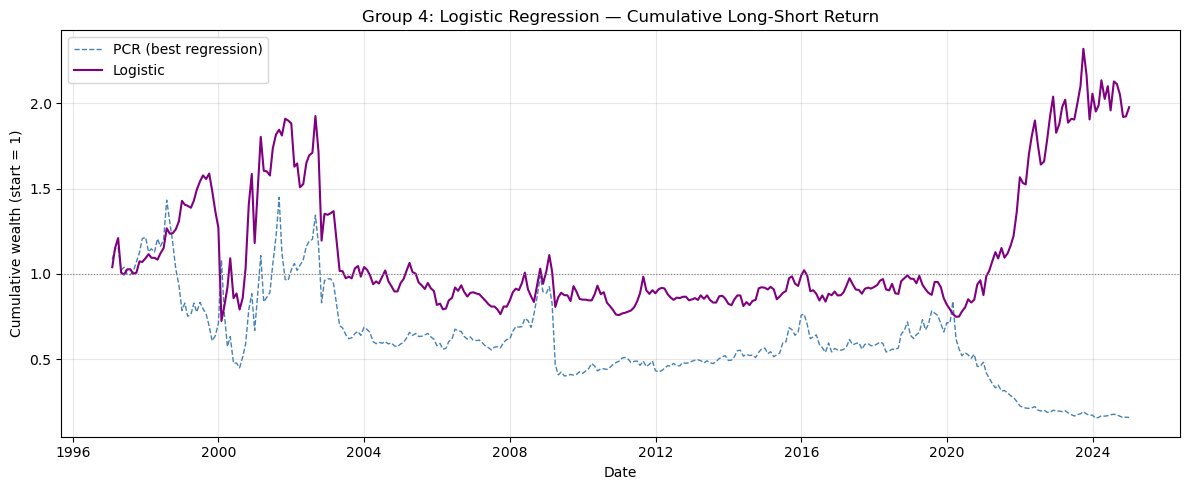

In [136]:
#visulize for Classifier
cum_logit = (1 + bt_logit['ls_ret'].dropna()).cumprod()
cum_pcr   = (1 + bt_pcr['ls_ret'].dropna()).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(cum_pcr.index,   cum_pcr.values,   label='PCR (best regression)', color='steelblue',  linewidth=1.0, linestyle='--')
plt.plot(cum_logit.index, cum_logit.values, label='Logistic',              color='purple',     linewidth=1.5)
plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
plt.title('Group 4: Logistic Regression — Cumulative Long-Short Return')
plt.ylabel('Cumulative wealth (start = 1)')
plt.xlabel('Date')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'group4_cumret.png'), dpi=150, bbox_inches='tight')
plt.show()

### Multinomial Logistic Regression (5-class, quintile)

Same idea as the binary Logit above, but instead of a median split we cut each month's
cross-sectional excess return into 5 quintiles (`y_multi` = 0..4, 4 = top quintile). The
model is a single softmax/multinomial `LogisticRegression` (sklearn uses multinomial loss
automatically once the target has more than 2 classes), refit every month on the same
rolling H-month window as every other model.

For the backtest we still need one score per stock to sort into deciles, so we use
`P(top quintile)` the same way the binary Logit used `P(class 1)`. We keep all 5 class
probabilities (`proba_0..proba_4`) around too, since multi-class accuracy/AUC need the
full distribution, not just the top class.


In [138]:
# Construct cross-sectional 5-class (quintile) label
# y_multi = 0..4, 4 = top quintile (highest next-period excess return), 0 = bottom quintile
panel['y_multi'] = (
    panel.groupby(DATE_COL)['y']
    .transform(lambda x: pd.qcut(x, 5, labels=False, duplicates='drop'))
)
panel.loc[panel['y'].isna(), 'y_multi'] = np.nan

panel_clf_multi = panel[['permno', DATE_COL, 'y', 'y_multi'] + FEATURE_COLS].copy()
panel_clf_multi[FEATURE_COLS] = panel_clf_multi[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
panel_clf_multi[FEATURE_COLS] = panel_clf_multi[FEATURE_COLS].astype('float32')

print('y_multi class balance:')
print(panel_clf_multi['y_multi'].value_counts(normalize=True).sort_index())

import gc
del panel  # not needed anymore; frees ~1GB+ on an 8GB machine for the heavy fits below
gc.collect()


y_multi class balance:
y_multi
0.0    0.200305
1.0    0.200125
2.0    0.199844
3.0    0.199725
4.0    0.200000
Name: proportion, dtype: float64


7708

In [ ]:
# ── Multinomial classification rolling forecast ───────────────────────────
'''
same logic as rolling_panel_forecast_clf, but the target now has n_classes (5) levels instead of 2. We keep every class's predicted probability (proba_0..proba_{n-1}) for multi-class accuracy/AUC, and use P(top class) as the ranking score for the backtest --the same role predict_proba[:, 1] played for the binary Logit.
'''
N_CLASSES = 5

def rolling_panel_forecast_multi(panel, feature_cols, target_col, date_col, h, model,
                                  n_classes, show_progress=True, start_i=None):
    month_starts = {}; month_ends = {}
    for month, grp in panel.groupby(date_col, sort=True):
        month_starts[month] = int(grp.index[0])
        month_ends[month]   = int(grp.index[-1]) + 1
    months = sorted(month_starts); n = len(months)

    if start_i is None:
        start_i = h

    records = []
    it = range(start_i, n)
    if show_progress:
        it = tqdm(it, total=n - start_i, desc='Rolling forecast (multinomial)')

    for i in it:
        row_s = month_starts[months[i - h]]; row_e = month_ends[months[i - 1]]
        pr_s  = month_starts[months[i]];     pr_e  = month_ends[months[i]]

        train = panel.iloc[row_s:row_e].dropna(subset=feature_cols + [target_col])
        pred  = panel.iloc[pr_s:pr_e].dropna(subset=feature_cols)

        if len(train) < 10 or len(pred) == 0: continue
        if train[target_col].nunique() < n_classes: continue  # need every class present to fit cleanly

        model.fit(train[feature_cols].values, train[target_col].values)
        proba = model.predict_proba(pred[feature_cols].values)

        out = pred[['permno', date_col, 'y', target_col, 'size']].copy()
        for k in range(n_classes):
            out[f'proba_{k}'] = proba[:, k]
        out['pred'] = proba[:, n_classes - 1]   # P(top quintile), used to rank deciles in the backtest
        records.append(out)

    if len(records) == 0:
        return pd.DataFrame()

    return pd.concat(records, ignore_index=True)


In [140]:
mlogit = Pipeline([
    ('sc', StandardScaler()),
    ('m',  LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')),
])

pred_mlogit = rolling_panel_forecast_multi(
    panel_clf_multi, FEATURE_COLS, 'y_multi', DATE_COL, H, mlogit, n_classes=N_CLASSES, start_i=TEST_START_I
)
print('Multinomial Logit done.  shape:', pred_mlogit.shape)
print(pred_mlogit.head())
import gc; gc.collect()


Rolling forecast (multinomial): 100%|██████████| 348/348 [25:45<00:00,  4.44s/it]


Multinomial Logit done.  shape: (769767, 11)
   permno   mthcaldt         y  y_multi       size   proba_0   proba_1  \
0   10025 1997-01-31  0.023802      3.0  12.845300  0.232379  0.203880   
1   10064 1997-01-31 -0.047053      1.0  12.922002  0.137182  0.202612   
2   10071 1997-01-31  0.092198      4.0  14.053348  0.240663  0.191057   
3   10075 1997-01-31  0.004674      2.0  12.626220  0.360260  0.161968   
4   10078 1997-01-31 -0.032059      2.0  16.273960  0.247262  0.158984   

    proba_2   proba_3   proba_4      pred  
0  0.183875  0.172398  0.207467  0.207467  
1  0.233094  0.232918  0.194193  0.194193  
2  0.175120  0.188751  0.204409  0.204409  
3  0.118770  0.117663  0.241340  0.241340  
4  0.150044  0.189898  0.253813  0.253813  


0

In [141]:
# ── Multinomial classification metrics ─────────────────────────────────────
proba_cols = [f'proba_{k}' for k in range(N_CLASSES)]
df_mlogit_eval = pred_mlogit.dropna(subset=['y_multi'] + proba_cols)
pred_class = df_mlogit_eval[proba_cols].values.argmax(axis=1)

acc_m = accuracy_score(df_mlogit_eval['y_multi'], pred_class)
auc_m = roc_auc_score(df_mlogit_eval['y_multi'], df_mlogit_eval[proba_cols].values, multi_class='ovr', average='macro')
print(f'Multinomial Logit  Accuracy: {acc_m:.4f}   Macro OVR AUC: {auc_m:.4f}   n: {len(df_mlogit_eval):,}')
stats_mlogit = {'Accuracy': round(acc_m, 4), 'AUC': round(auc_m, 4)}


Multinomial Logit  Accuracy: 0.2545   Macro OVR AUC: 0.5872   n: 766,129


In [142]:
# ── Backtest of Multinomial Logit ───────────────────────────────────────────
bt_mlogit       = panel_backtest(pred_mlogit, date_col=DATE_COL, n_deciles=N_DECILES)
metrics_mlogit  = backtest_metrics(bt_mlogit)
print('Multinomial Logit backtest:', metrics_mlogit)

summary_g4b = pd.DataFrame({'Multinomial Logit': {**stats_mlogit, **metrics_mlogit}}).T
print(summary_g4b.to_string())
summary_g4b.to_csv(os.path.join(OUT_DIR, 'metrics_group4b.csv'))


Multinomial Logit backtest: {'Sharpe (annual)': -0.086, 'Volatility (annual)': 0.3283, 'Cumulative return': -0.898, 'Max drawdown': -0.964, 'Average monthly ret': -0.00236}
                   Accuracy     AUC  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret
Multinomial Logit    0.2545  0.5872           -0.086               0.3283             -0.898        -0.964             -0.00236


## 8. Summary — All Models

=== Full Model Comparison (equal-weight long-short) ===
                        MSE  R2_oos  Sharpe (annual)  Volatility (annual)  Cumulative return  Max drawdown  Average monthly ret  Accuracy     AUC
OLS                0.020974 -0.0140            0.045               0.1853             -0.223        -0.609              0.00070       NaN     NaN
Ridge              0.021008 -0.0156           -0.090               0.1785             -0.594        -0.720             -0.00133       NaN     NaN
Lasso              0.021000 -0.0152           -0.102               0.1804             -0.625        -0.730             -0.00154       NaN     NaN
PCR                0.020734 -0.0024           -0.065               0.3003             -0.842        -0.894             -0.00164       NaN     NaN
PLS                0.020980 -0.0143           -0.020               0.1800             -0.430        -0.623             -0.00031       NaN     NaN
Tree               0.022103 -0.0686            0.160               0

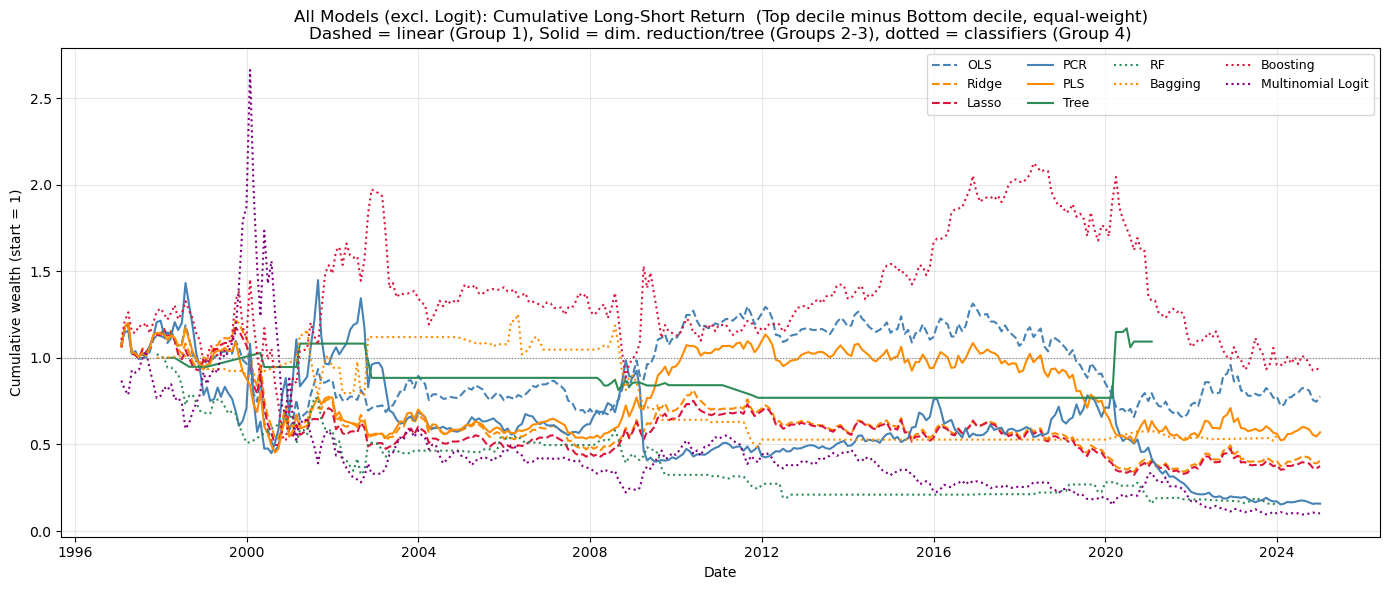

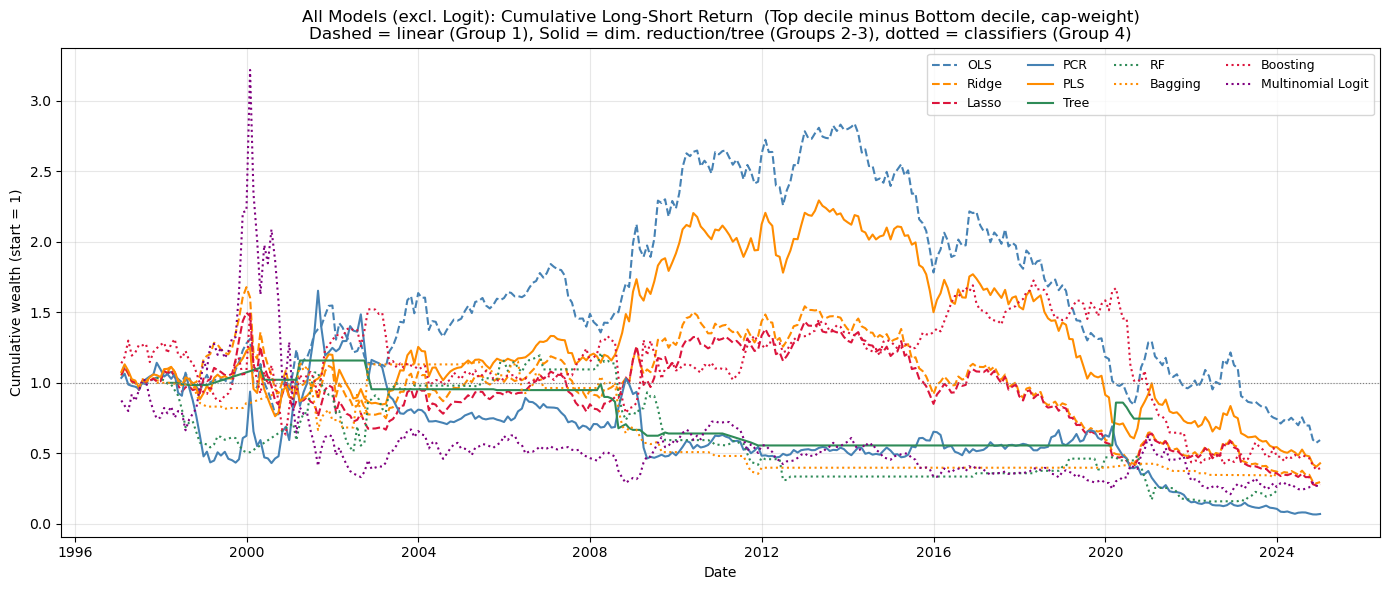

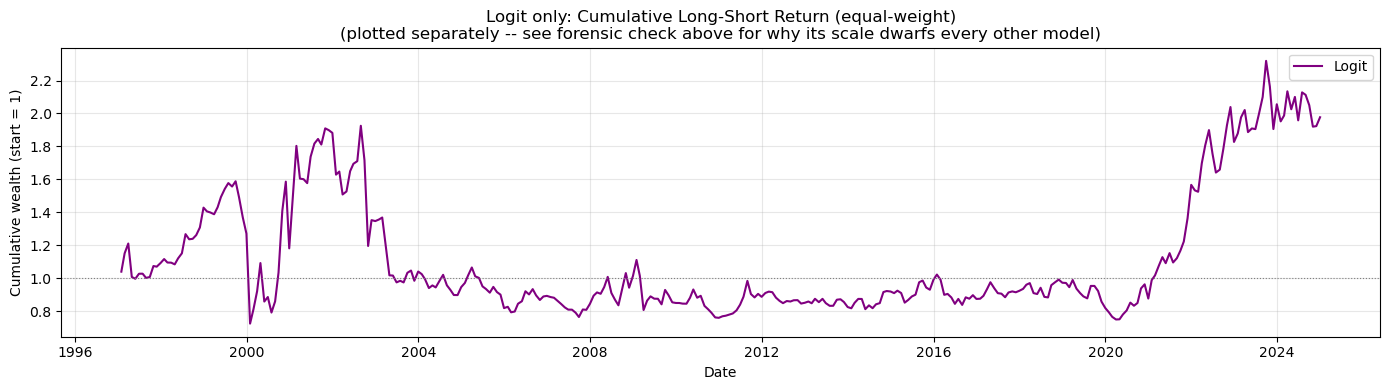

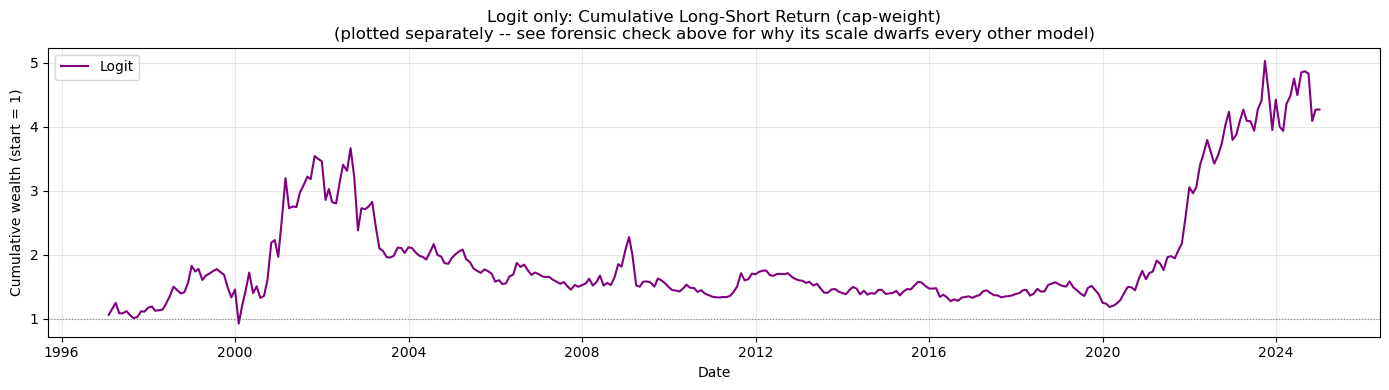

Saved: metrics_all.csv, metrics_all_cap.csv, all_models_cumret.png, all_models_cumret_cap.png, logit_cumret.png, logit_cumret_cap.png


In [150]:
# ── Use in-memory predictions ───────────────────────────────────────────────
preds_reg = {
    'OLS':   pred_ols,
    'Ridge': pred_ridge,
    'Lasso': pred_lasso,
    'PCR':   pred_pcr,
    'PLS':   pred_pls,
    'Tree':  pred_tree,
    'RF':       pred_rf,
    'Bagging':  pred_bagging,
    'Boosting': pred_boosting,
}

def build_summary(weighting):
    # weighting: 'equal' or 'cap'. Returns (bt_dict, rows) for this weighting scheme,
    # across every regression model plus the binary and multinomial classifiers.
    bt_dict, rows = {}, {}
    for name, p in preds_reg.items():
        df = p.dropna(subset=['y', 'pred'])
        rows[name] = {
            'MSE':    round(mse(df['y'], df['pred']), 8),
            'R2_oos': round(r2_oos(df['y'], df['pred']), 4),
        }
        bt = panel_backtest(p, date_col=DATE_COL, n_deciles=N_DECILES, weighting=weighting)
        bt_dict[name] = bt
        rows[name].update(backtest_metrics(bt))

    df_logit_eval = pred_logit.dropna(subset=['y_bin', 'pred'])
    rows['Logit'] = {
        'Accuracy': round(accuracy_score(df_logit_eval['y_bin'], (df_logit_eval['pred'] >= 0.5).astype(int)), 4),
        'AUC':      round(roc_auc_score(df_logit_eval['y_bin'], df_logit_eval['pred']), 4),
    }
    bt_logit = panel_backtest(pred_logit, date_col=DATE_COL, n_deciles=N_DECILES, weighting=weighting)
    bt_dict['Logit'] = bt_logit
    rows['Logit'].update(backtest_metrics(bt_logit))

    proba_cols = [f'proba_{k}' for k in range(N_CLASSES)]
    df_mlogit_eval = pred_mlogit.dropna(subset=['y_multi'] + proba_cols)
    pred_class = df_mlogit_eval[proba_cols].values.argmax(axis=1)
    rows['Multinomial Logit'] = {
        'Accuracy': round(accuracy_score(df_mlogit_eval['y_multi'], pred_class), 4),
        'AUC':      round(roc_auc_score(df_mlogit_eval['y_multi'], df_mlogit_eval[proba_cols].values, multi_class='ovr', average='macro'), 4),
    }
    bt_mlogit = panel_backtest(pred_mlogit, date_col=DATE_COL, n_deciles=N_DECILES, weighting=weighting)
    bt_dict['Multinomial Logit'] = bt_mlogit
    rows['Multinomial Logit'].update(backtest_metrics(bt_mlogit))

    return bt_dict, rows

all_bt,     all_rows     = build_summary('equal')
all_bt_cap, all_rows_cap = build_summary('cap')

summary_all     = pd.DataFrame(all_rows).T
summary_all_cap = pd.DataFrame(all_rows_cap).T
print('=== Full Model Comparison (equal-weight long-short) ===')
print(summary_all.to_string())
print()
print('=== Full Model Comparison (cap-weight long-short) ===')
print(summary_all_cap.to_string())

summary_all.to_csv(os.path.join(OUT_DIR, 'metrics_all.csv'))
summary_all_cap.to_csv(os.path.join(OUT_DIR, 'metrics_all_cap.csv'))

# ── Cumulative L-S return: all models on one chart, equal-weight vs cap-weight ──
# Logit is excluded from this shared-axis chart and plotted on its own further below: its
# cumulative return is on a wildly different scale (the forensic check earlier found it's
# driven by the short leg catching a handful of penny-stock single-month crashes, not a
# diversified signal), so sharing an axis with it flattens every other model's curve near 0.
colors = {
    'OLS':   ('steelblue',  '--'),
    'Ridge': ('darkorange', '--'),
    'Lasso': ('crimson',    '--'),
    'PCR':   ('steelblue',  '-'),
    'PLS':   ('darkorange', '-'),
    'Tree':  ('seagreen',   '-'),
    'RF':       ('seagreen',  ':'),
    'Bagging':  ('darkorange', ':'),
    'Boosting': ('crimson',    ':'),
    'Multinomial Logit': ('purple', ':'),
}

for bt_dict, weight_label, fname in [
    (all_bt,     'equal-weight', 'all_models_cumret.png'),
    (all_bt_cap, 'cap-weight',   'all_models_cumret_cap.png'),
]:
    plt.figure(figsize=(14, 6))
    for name, (color, ls) in colors.items():
        cum = (1 + bt_dict[name]['ls_ret'].dropna()).cumprod()
        plt.plot(cum.index, cum.values, label=name, color=color, linestyle=ls, linewidth=1.5)
    plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    plt.title(f'All Models (excl. Logit): Cumulative Long-Short Return  (Top decile minus Bottom decile, {weight_label})\n'
              'Dashed = linear (Group 1), Solid = dim. reduction/tree (Groups 2-3), dotted = classifiers (Group 4)')
    plt.ylabel('Cumulative wealth (start = 1)')
    plt.xlabel('Date')
    plt.legend(ncol=4, fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()

# Logit plotted separately, own y-axis scale
for bt_dict, weight_label, fname in [
    (all_bt,     'equal-weight', 'logit_cumret.png'),
    (all_bt_cap, 'cap-weight',   'logit_cumret_cap.png'),
]:
    cum = (1 + bt_dict['Logit']['ls_ret'].dropna()).cumprod()
    plt.figure(figsize=(14, 4))
    plt.plot(cum.index, cum.values, label='Logit', color='purple', linewidth=1.5)
    plt.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
    plt.title(f'Logit only: Cumulative Long-Short Return ({weight_label})\n'
              '(plotted separately -- see forensic check above for why its scale dwarfs every other model)')
    plt.ylabel('Cumulative wealth (start = 1)')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()

print('Saved: metrics_all.csv, metrics_all_cap.csv, all_models_cumret.png, all_models_cumret_cap.png, logit_cumret.png, logit_cumret_cap.png')

### When do the biggest drawdowns happen, model by model

For each model we find the months with the worst drawdown (biggest drop from the running peak),
and then plot every model's drawdown curve on the same chart. If the dips line up across models
at the same dates, that points to market-wide stress hitting everyone at once. If a model dips
on its own at different dates than the others, that points to risk specific to that model
(it is reacting to something the others are not).

=== Worst drawdown months, per model ===

OLS:
mthcaldt
2000-08-31   -0.609285
2000-09-29   -0.586740
2000-07-31   -0.565060
2000-12-29   -0.514197
2000-06-30   -0.509853

Ridge:
mthcaldt
2020-08-31   -0.719584
2021-10-29   -0.718049
2021-09-30   -0.713013
2021-11-30   -0.710068
2020-06-30   -0.708724

Lasso:
mthcaldt
2020-08-31   -0.729598
2021-10-29   -0.724242
2020-06-30   -0.719159
2021-11-30   -0.718990
2021-09-30   -0.718920

PCR:
mthcaldt
2024-01-31   -0.894160
2024-10-31   -0.891780
2024-12-31   -0.890923
2024-02-29   -0.890663
2024-11-29   -0.889957

PLS:
mthcaldt
2000-08-31   -0.623348
2000-09-29   -0.602959
2000-07-31   -0.590023
2020-08-31   -0.573524
2024-01-31   -0.563883

Tree:
mthcaldt
2020-02-28   -0.289084
2016-12-30   -0.289084
2011-11-30   -0.289084
2011-09-30   -0.273056
2008-08-29   -0.247765

RF:
mthcaldt
2023-11-30   -0.847349
2023-10-31   -0.846518
2021-01-29   -0.844731
2023-03-31   -0.842571
2023-09-29   -0.841706

Bagging:
mthcaldt
2011-11-30   -0.614985
201

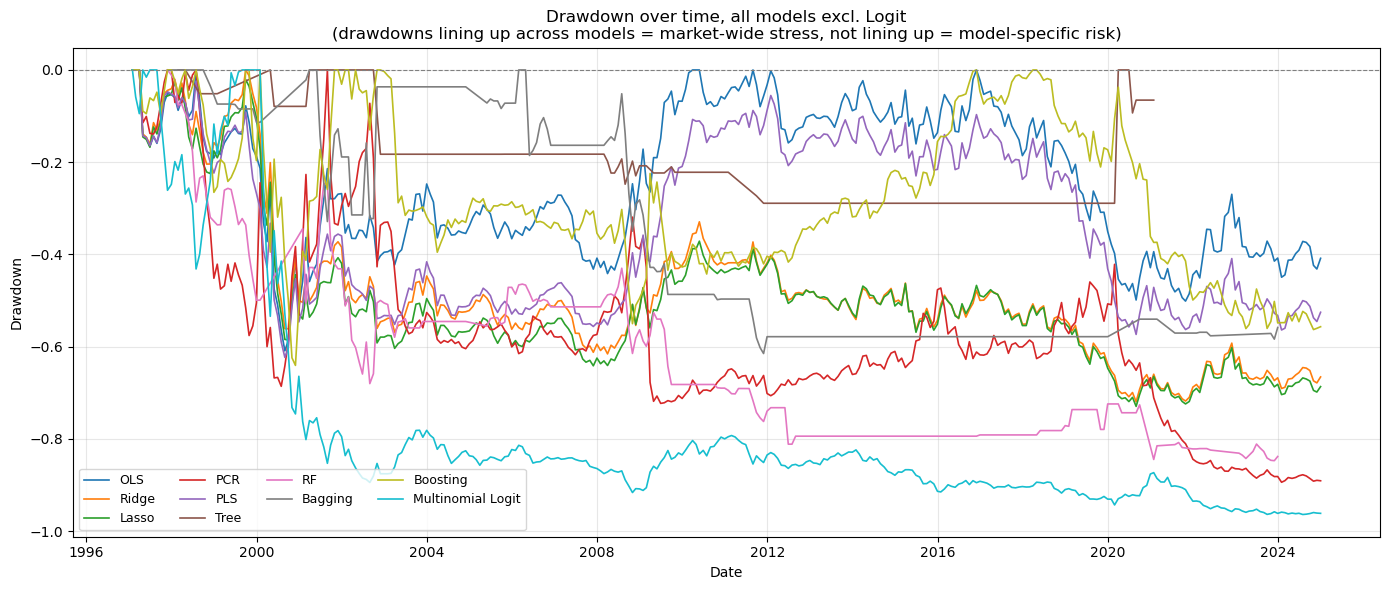

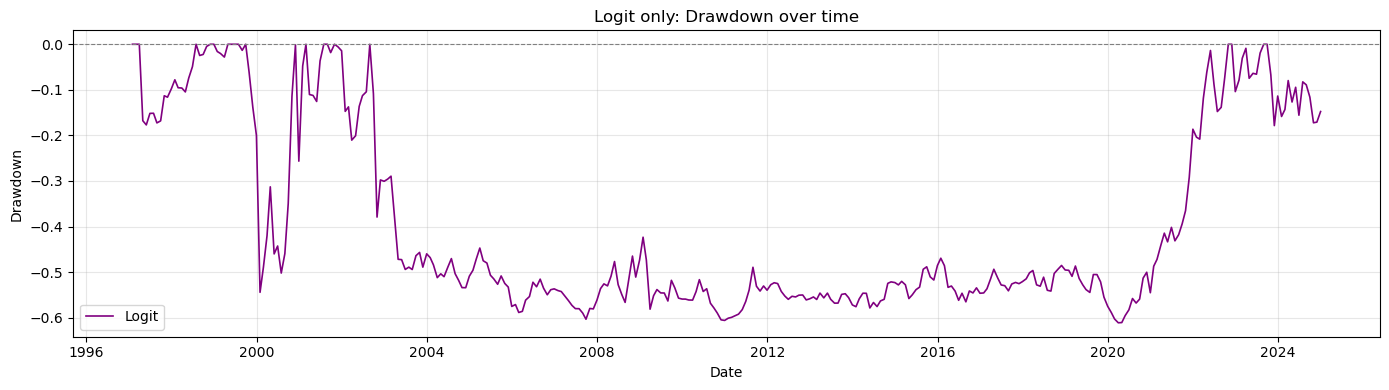

In [152]:
# ── When do the biggest drawdowns happen, and for which models? ────────────
def worst_drawdowns(bt_df, n_top=5):
    r = bt_df['ls_ret'].dropna()
    wealth = (1 + r).cumprod()
    drawdown = (wealth - wealth.expanding().max()) / wealth.expanding().max()
    return drawdown.sort_values().head(n_top)

print('=== Worst drawdown months, per model ===')
for name, bt in all_bt.items():
    print(f'\n{name}:')
    print(worst_drawdowns(bt, n_top=5).to_string())

# plot drawdown curves for all models together, so we can see if the big
# drawdowns happen at the same time (market-wide stress) or at different
# times (model-specific risk). Logit excluded here too (see cumret plot above) and
# plotted on its own below, for the same reason.
plt.figure(figsize=(14, 6))
for name, bt in all_bt.items():
    if name == 'Logit':
        continue
    r = bt['ls_ret'].dropna()
    wealth = (1 + r).cumprod()
    drawdown = (wealth - wealth.expanding().max()) / wealth.expanding().max()
    plt.plot(drawdown.index, drawdown.values, label=name, linewidth=1.2)
plt.axhline(0.0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Drawdown over time, all models excl. Logit\n'
          '(drawdowns lining up across models = market-wide stress, not lining up = model-specific risk)')
plt.ylabel('Drawdown')
plt.xlabel('Date')
plt.legend(ncol=4, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'all_models_drawdown.png'), dpi=150, bbox_inches='tight')
plt.show()

# Logit drawdown, plotted separately
r = all_bt['Logit']['ls_ret'].dropna()
wealth = (1 + r).cumprod()
drawdown = (wealth - wealth.expanding().max()) / wealth.expanding().max()
plt.figure(figsize=(14, 4))
plt.plot(drawdown.index, drawdown.values, label='Logit', color='purple', linewidth=1.2)
plt.axhline(0.0, color='gray', linewidth=0.8, linestyle='--')
plt.title('Logit only: Drawdown over time')
plt.ylabel('Drawdown')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'logit_drawdown.png'), dpi=150, bbox_inches='tight')
plt.show()